In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
!pip install ydata-profiling
from ydata_profiling import ProfileReport

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple
  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl.metadata (23 kB)
  Using cached matplotlib-3.10.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached minify_html-0.18.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached phik-0.12.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
  Using cached typeguard-4.5.2-py3-none-any.whl.metadata (3.8 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached wordcloud-1.9.6-cp3

/tmp/ipykernel_88/3439640783.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
# Gemeinsamen Merge laden und an die bisherigen Analysen anpassen
from pathlib import Path


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Repository-Wurzel mit .git wurde nicht gefunden.")


MERGED_FILE = (
    find_repo_root()
    / "dataset"
    / "cleaned"
    / "merged"
    / "all_sources_attacks_merged_analysis_ready.csv"
)
if not MERGED_FILE.exists():
    raise FileNotFoundError(
        f"Merge-Datei fehlt: {MERGED_FILE}\n"
        "Bitte zuerst dataset/raw/Merge all files.ipynb vollständig ausführen."
    )

df = pd.read_csv(MERGED_FILE, low_memory=False)
required = {"age_reg", "patient_id", "attack_datetime", "weekday_raw", "headache", "migraine"}
missing = sorted(required - set(df.columns))
if missing:
    raise KeyError(f"Pflichtspalten im gemeinsamen Merge fehlen: {missing}")

rows_before = len(df)
df["age_reg"] = pd.to_numeric(df["age_reg"], errors="coerce")
df = df.loc[df["age_reg"].ge(18)].copy()
df = df.rename(columns={
    "patient_id": "patient_info_id",
    "attack_datetime": "attack_time",
    "weekday_raw": "weekday",
})

bool_map = {
    "true": True, "1": True, "1.0": True, "yes": True, "ja": True, "wahr": True,
    "false": False, "0": False, "0.0": False, "no": False, "nein": False, "falsch": False,
}
for column in [
    "headache", "migraine", "comment_menstruation",
    "symptoms_both_side_headache", "symptoms_one_side_headache",
    "symptoms_pulsating_headache", "symptoms_dull_headache",
]:
    if column in df.columns:
        df[column] = df[column].astype("string").str.strip().str.lower().map(bool_map).astype("boolean")

print("Loaded file:", MERGED_FILE)
print("Zeilen vor Altersfilter:", rows_before)
print("Zeilen nach age_reg >= 18:", len(df))
print("Entfernte Zeilen:", rows_before - len(df))


In [3]:
df.columns

Index(['patient_info_id', 'headache', 'migraine', 'attack_time', 'intensity',
       'duration', 'symptoms_both_side_headache', 'symptoms_one_side_headache',
       'symptoms_pulsating_headache', 'symptoms_dull_headache', 'weekday',
       'date_registration', 'gender', 'birthyear', 'entries_app',
       'first_app_entry', 'last_app_entry', 'period_use_app',
       'headache_entries_app', 'migraine_entries_app', 'age', 'year', 'month'],
      dtype='object')

In [4]:
df.dtypes

patient_info_id                  int64
headache                          bool
migraine                          bool
attack_time                     object
intensity                        int64
duration                         int64
symptoms_both_side_headache       bool
symptoms_one_side_headache        bool
symptoms_pulsating_headache       bool
symptoms_dull_headache            bool
weekday                         object
date_registration               object
gender                          object
birthyear                        int64
entries_app                    float64
first_app_entry                 object
last_app_entry                  object
period_use_app                 float64
headache_entries_app           float64
migraine_entries_app           float64
age                              int64
year                             int64
month                            int64
dtype: object

In [5]:
df.head()

,patient_info_id,headache,migraine,attack_time,intensity,duration,symptoms_both_side_headache,symptoms_one_side_headache,symptoms_pulsating_headache,symptoms_dull_headache,...,birthyear,entries_app,first_app_entry,last_app_entry,period_use_app,headache_entries_app,migraine_entries_app,age,year,month
0,10007520,True,False,2023-06-21 00:00:00,6,900,True,False,True,False,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6
1,10007520,True,False,2023-06-24 00:00:00,7,300,True,False,True,False,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6
2,10007520,True,False,2023-06-25 00:00:00,5,480,True,False,True,False,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6
3,10007520,True,False,2023-06-26 00:00:00,4,300,True,False,True,False,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6
4,10007520,True,False,2023-06-27 00:00:00,8,900,True,False,True,True,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6


In [6]:
df.isnull().any()

patient_info_id                False
headache                       False
migraine                       False
attack_time                    False
intensity                      False
duration                       False
symptoms_both_side_headache    False
symptoms_one_side_headache     False
symptoms_pulsating_headache    False
symptoms_dull_headache         False
weekday                        False
date_registration              False
gender                         False
birthyear                      False
entries_app                    False
first_app_entry                False
last_app_entry                 False
period_use_app                 False
headache_entries_app           False
migraine_entries_app           False
age                            False
year                           False
month                          False
dtype: bool

In [7]:
cols = ["attack_time","date_registration","first_app_entry","last_app_entry"]

df[cols] = df[cols].apply(pd.to_datetime, errors="coerce")

In [8]:
df.dtypes

patient_info_id                         int64
headache                                 bool
migraine                                 bool
attack_time                    datetime64[ns]
intensity                               int64
duration                                int64
symptoms_both_side_headache              bool
symptoms_one_side_headache               bool
symptoms_pulsating_headache              bool
symptoms_dull_headache                   bool
weekday                                object
date_registration              datetime64[ns]
gender                                 object
birthyear                               int64
entries_app                           float64
first_app_entry                datetime64[ns]
last_app_entry                 datetime64[ns]
period_use_app                        float64
headache_entries_app                  float64
migraine_entries_app                  float64
age                                     int64
year                              

In [9]:
df.head()

,patient_info_id,headache,migraine,attack_time,intensity,duration,symptoms_both_side_headache,symptoms_one_side_headache,symptoms_pulsating_headache,symptoms_dull_headache,...,birthyear,entries_app,first_app_entry,last_app_entry,period_use_app,headache_entries_app,migraine_entries_app,age,year,month
0,10007520,True,False,2023-06-21,6,900,True,False,True,False,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6
1,10007520,True,False,2023-06-24,7,300,True,False,True,False,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6
2,10007520,True,False,2023-06-25,5,480,True,False,True,False,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6
3,10007520,True,False,2023-06-26,4,300,True,False,True,False,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6
4,10007520,True,False,2023-06-27,8,900,True,False,True,True,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6


In [10]:
attacks_over_time = df.groupby("attack_time").size()

In [11]:
attacks_over_time

attack_time
2020-06-22       1
2020-06-25       1
2020-06-26       1
2020-06-27       1
2020-06-29       1
              ... 
2026-02-11    1044
2026-02-12    1001
2026-02-13    1000
2026-02-14     966
2026-02-15     887
Length: 2062, dtype: int64

<Axes: xlabel='attack_time'>

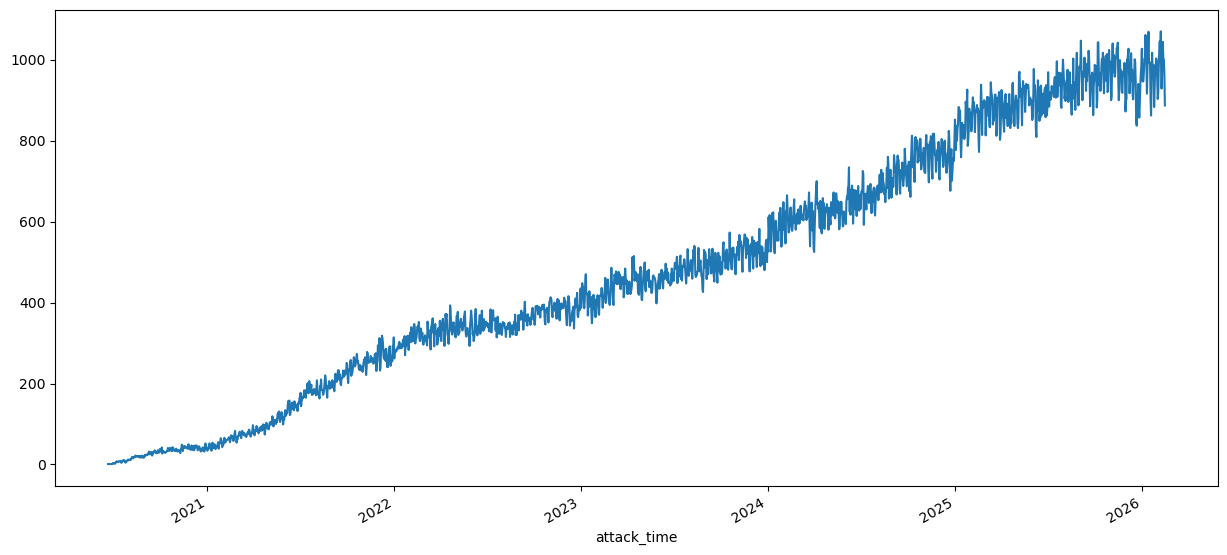

In [12]:
attacks_over_time.plot(figsize=(15,7))
#but this can also mean that the number of app users increased over time,
#this does not mean attacks increased over time but it means more users were recorded

In [13]:
#so lets try something new , attacks per active patient,  it removes user growth bias
daily_attacks = df.groupby("attack_time").size()
daily_users = df.groupby("attack_time")["patient_info_id"].nunique()
attack_rate = daily_attacks / daily_users

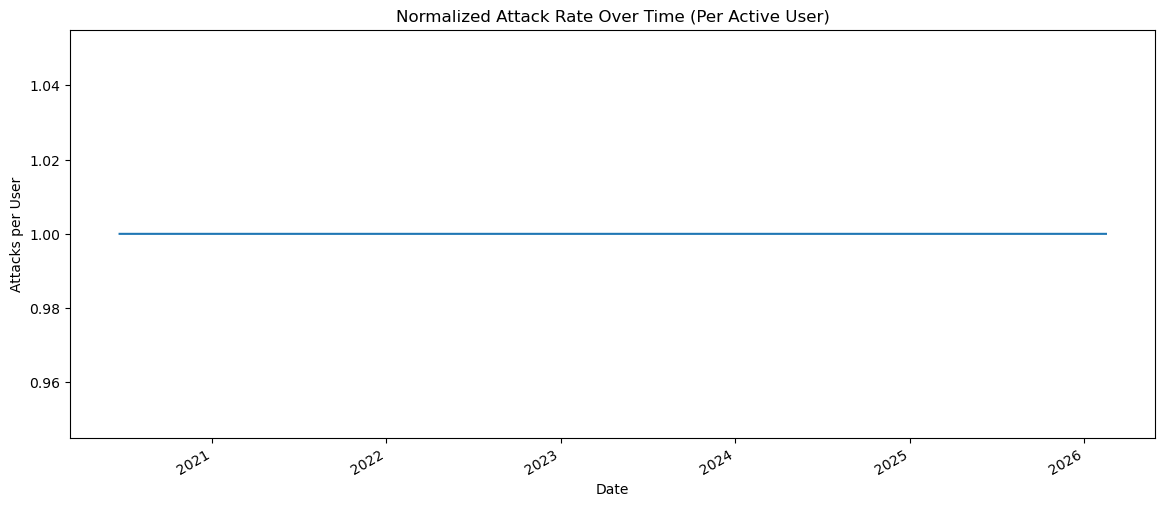

In [14]:
plt.figure(figsize=(14,6))

attack_rate.plot()

plt.title("Normalized Attack Rate Over Time (Per Active User)")
plt.xlabel("Date")
plt.ylabel("Attacks per User")

plt.show()

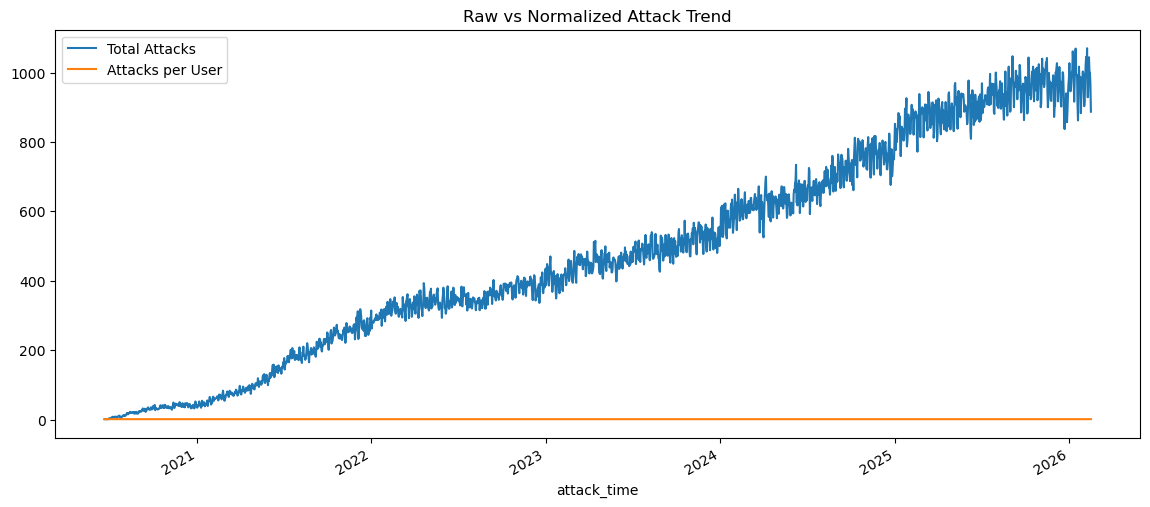

In [15]:
plt.figure(figsize=(14,6))

daily_attacks.plot(label="Total Attacks")
attack_rate.plot(label="Attacks per User")

plt.legend()
plt.title("Raw vs Normalized Attack Trend")
plt.show()

In [16]:
#lets analyse the patient we have per year
patients_per_year = df.groupby("year")["patient_info_id"].nunique()

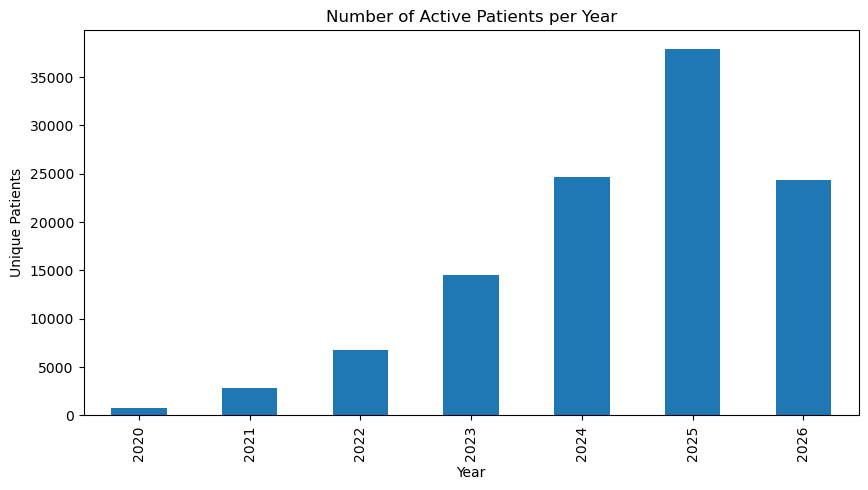

In [17]:
patients_per_year.plot(kind="bar", figsize=(10,5))

plt.title("Number of Active Patients per Year")
plt.xlabel("Year")
plt.ylabel("Unique Patients")

plt.show()

In [18]:
#lets see the number of attacks per year
attacks_per_year = df.groupby("year").size()
#rate of attack per year
attack_rate_per_year = attacks_per_year / patients_per_year

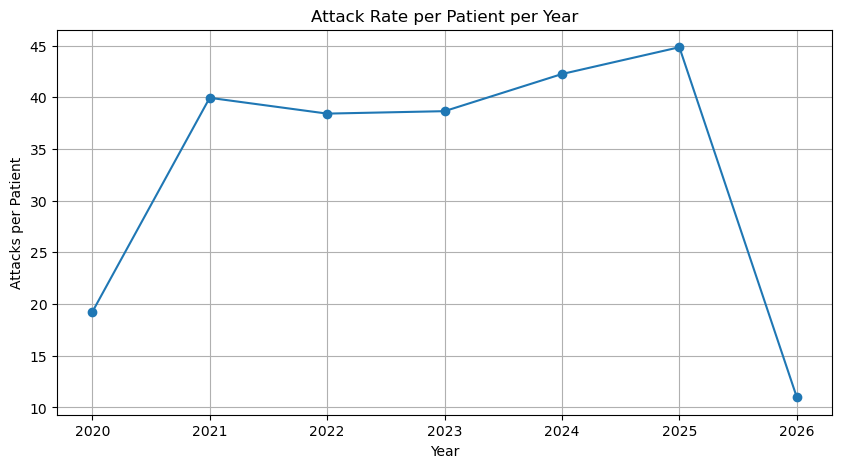

In [19]:
plt.figure(figsize=(10,5))

attack_rate_per_year.plot(marker="o")

plt.title("Attack Rate per Patient per Year")
plt.xlabel("Year")
plt.ylabel("Attacks per Patient")

plt.grid(True)
plt.show()

In [20]:
weekdays= df["weekday"].value_counts()

<Axes: xlabel='weekday'>

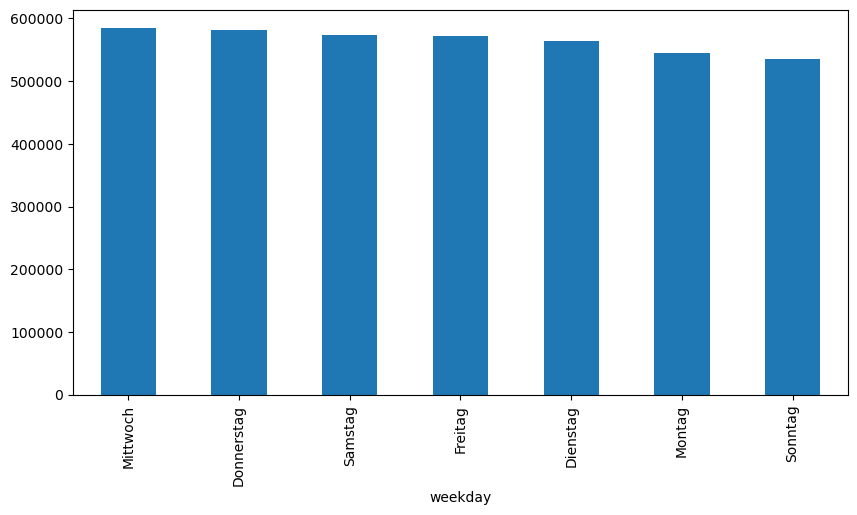

In [21]:
weekdays.plot(kind="bar", figsize=(10,5))

In [22]:
months=df["month"].value_counts().sort_index()

<Axes: xlabel='month'>

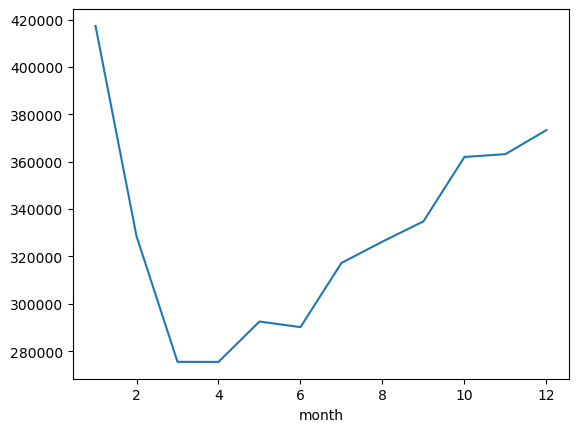

In [23]:
months.plot()

In [24]:
df["month"].dtypes

dtype('int64')

In [25]:
# actual normalization start here   finding the earliest and latest dates and number of months the attacks were registered each year

In [26]:
#min and max date
print(df["attack_time"].min())
print(df["attack_time"].max())

2020-06-22 00:00:00
2026-02-15 00:00:00


In [27]:
df.groupby("year")["month"].nunique()

year
2020     7
2021    12
2022    12
2023    12
2024    12
2025    12
2026     2
Name: month, dtype: int64

In [28]:
# now the actual analysis will start

In [29]:
df_full=df

In [30]:
df_full["year"].unique()

array([2023, 2024, 2021, 2025, 2026, 2022, 2020])

In [31]:
df_full["patient_info_id"].nunique()

61622

In [32]:
df = df[(df["year"] != 2026) & (df["year"] != 2020)]

In [33]:
df["year"].value_counts().sort_index()

year
2021     113602
2022     258429
2023     559229
2024    1041526
2025    1701943
Name: count, dtype: int64

In [34]:
all_days = pd.date_range(
    start=df["attack_time"].min(),
    end=df["attack_time"].max(),
    freq="D"
)

In [35]:
len(all_days)

1826

In [36]:
all_days

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=1826, freq='D')

In [37]:
daily_attacks = df.groupby("attack_time").size()

In [38]:
daily_attacks.head()

attack_time
2021-01-01    42
2021-01-02    34
2021-01-03    39
2021-01-04    40
2021-01-05    39
dtype: int64

In [39]:
daily_attacks = daily_attacks.reindex(
    all_days,
    fill_value=0
)

In [40]:
daily_attacks.head()

2021-01-01    42
2021-01-02    34
2021-01-03    39
2021-01-04    40
2021-01-05    39
Freq: D, dtype: int64

In [41]:
day = pd.Timestamp("2021-01-01")

In [42]:
active = (
    (df["first_app_entry"] <= day) &
    (df["last_app_entry"] >= day)
)

In [43]:
#condition on the columns and the rows
n_active = df.loc[active, "patient_info_id"].nunique()

In [44]:
n_active

114

In [45]:
daily_participants = []

for day in all_days:
    
    active = (
        (df["first_app_entry"] <= day) &
        (df["last_app_entry"] >= day)
    )
    
    n_active = df.loc[
        active,
        "patient_info_id"
    ].nunique()
    
    daily_participants.append(n_active)

In [46]:
daily_participants

[114,
 114,
 114,
 115,
 115,
 116,
 116,
 118,
 118,
 120,
 122,
 124,
 125,
 126,
 126,
 127,
 130,
 129,
 129,
 130,
 132,
 132,
 134,
 134,
 135,
 135,
 136,
 138,
 138,
 138,
 139,
 147,
 147,
 150,
 152,
 153,
 154,
 157,
 158,
 162,
 164,
 165,
 165,
 165,
 167,
 168,
 170,
 172,
 172,
 172,
 174,
 174,
 175,
 178,
 179,
 179,
 182,
 183,
 185,
 190,
 191,
 195,
 197,
 198,
 198,
 198,
 200,
 202,
 204,
 204,
 205,
 207,
 207,
 207,
 208,
 209,
 210,
 212,
 212,
 213,
 214,
 214,
 215,
 216,
 216,
 218,
 220,
 223,
 223,
 226,
 228,
 232,
 231,
 232,
 233,
 236,
 237,
 238,
 240,
 240,
 241,
 242,
 244,
 245,
 245,
 248,
 249,
 252,
 251,
 253,
 253,
 255,
 256,
 257,
 258,
 264,
 264,
 265,
 265,
 267,
 272,
 274,
 282,
 288,
 294,
 298,
 303,
 304,
 309,
 314,
 316,
 321,
 323,
 326,
 327,
 330,
 337,
 339,
 342,
 343,
 346,
 350,
 354,
 357,
 361,
 363,
 365,
 367,
 367,
 368,
 375,
 384,
 386,
 386,
 389,
 392,
 394,
 399,
 405,
 409,
 412,
 413,
 417,
 418,
 426,
 430,
 435

In [47]:
len(daily_participants)

1826

In [48]:
daily_participants = pd.Series(
    daily_participants,
    index=all_days
)

In [49]:
daily_participants.head()

2021-01-01    114
2021-01-02    114
2021-01-03    114
2021-01-04    115
2021-01-05    115
Freq: D, dtype: int64

In [50]:
daily_attacks.index = pd.to_datetime(daily_attacks.index)
daily_participants.index = pd.to_datetime(daily_participants.index)

In [51]:
daily_rate = daily_attacks / daily_participants

In [52]:
daily_rate.head()

2021-01-01    0.368421
2021-01-02    0.298246
2021-01-03    0.342105
2021-01-04    0.347826
2021-01-05    0.339130
Freq: D, dtype: float64

In [53]:
daily_rate.isna().sum()

np.int64(0)

In [54]:
daily_rate.describe()   #What i now have is:Incidence intensity per active user per day 
                       #This is MUCH better than raw counts because it corrects for: changing user baseapp growth varying participation*/

count    1826.000000
mean        0.290355
std         0.032316
min         0.227564
25%         0.268876
50%         0.284312
75%         0.304188
max         0.471014
dtype: float64

In [55]:
monthly_rate  = daily_rate.resample("ME").mean()
print(monthly_rate)


2021-01-31    0.363879
2021-02-28    0.378409
2021-03-31    0.358865
2021-04-30    0.356573
2021-05-31    0.330591
2021-06-30    0.327046
2021-07-31    0.335220
2021-08-31    0.310010
2021-09-30    0.316984
2021-10-31    0.318745
2021-11-30    0.308432
2021-12-31    0.307767
2022-01-31    0.309966
2022-02-28    0.314817
2022-03-31    0.300909
2022-04-30    0.301481
2022-05-31    0.289254
2022-06-30    0.279590
2022-07-31    0.276892
2022-08-31    0.266378
2022-09-30    0.278311
2022-10-31    0.275419
2022-11-30    0.274247
2022-12-31    0.261581
2023-01-31    0.267818
2023-02-28    0.265854
2023-03-31    0.278043
2023-04-30    0.270539
2023-05-31    0.261544
2023-06-30    0.260413
2023-07-31    0.264480
2023-08-31    0.261919
2023-09-30    0.260816
2023-10-31    0.258850
2023-11-30    0.264271
2023-12-31    0.253718
2024-01-31    0.271462
2024-02-29    0.276991
2024-03-31    0.274937
2024-04-30    0.272612
2024-05-31    0.268466
2024-06-30    0.271758
2024-07-31    0.269691
2024-08-31 

In [56]:
yearly_rate   = daily_rate.resample("YE").mean()
print(yearly_rate)


2021-12-31    0.334093
2022-12-31    0.285524
2023-12-31    0.264007
2024-12-31    0.274356
2025-12-31    0.293838
Freq: YE-DEC, dtype: float64


In [57]:
weekly_rate   = daily_rate.groupby(daily_rate.index.dayofweek).mean()
print(weekly_rate)

0    0.277998
1    0.288701
2    0.298279
3    0.298480
4    0.296440
5    0.295135
6    0.277481
dtype: float64


In [58]:
weekly_mean = daily_rate.groupby(daily_rate.index.dayofweek).mean()

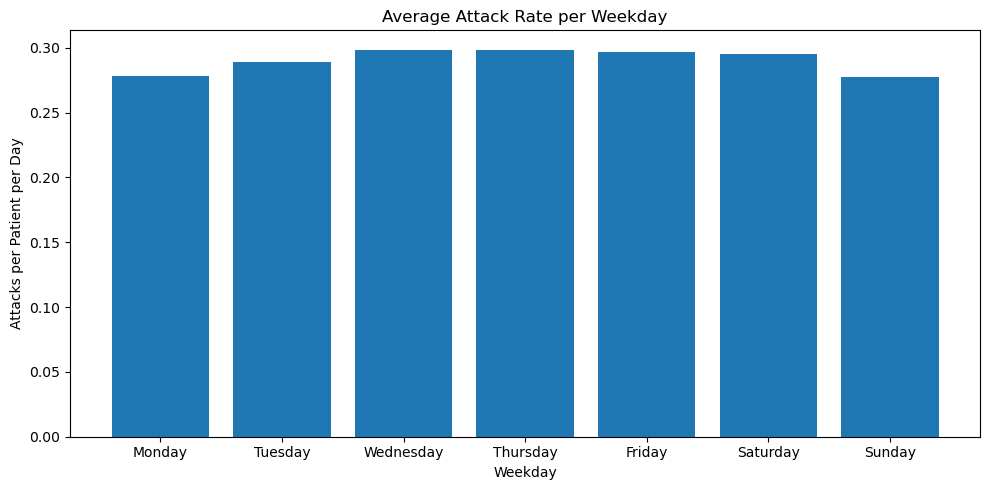

In [59]:
#weeekly pattern


import matplotlib.pyplot as plt

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
plt.bar(days, weekly_rate)
plt.title('Average Attack Rate per Weekday')
plt.xlabel('Weekday')
plt.ylabel('Attacks per Patient per Day')
plt.tight_layout()
plt.show()

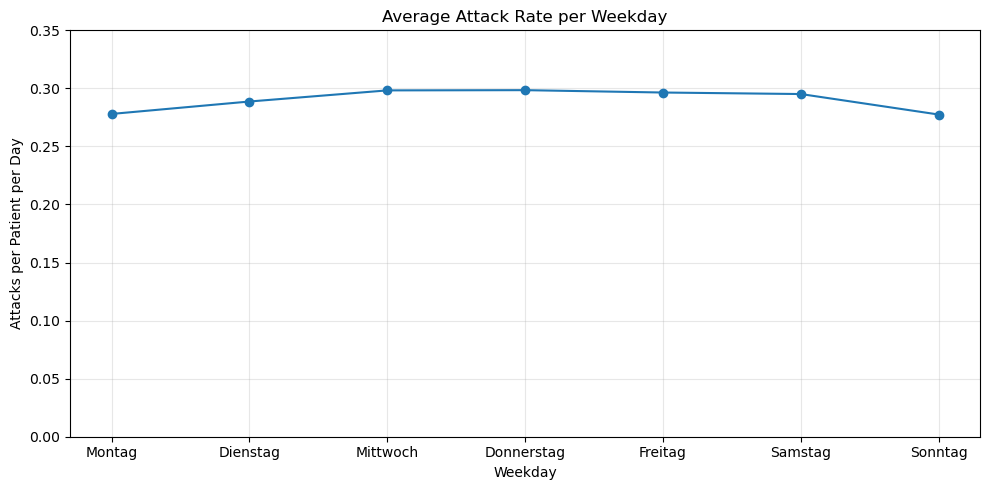

In [60]:
import matplotlib.pyplot as plt

days = ['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']

plt.figure(figsize=(10, 5))
plt.plot(days, weekly_rate, marker='o')
plt.title('Average Attack Rate per Weekday')
plt.xlabel('Weekday')
plt.ylabel('Attacks per Patient per Day')
plt.grid(True, alpha=0.3)
plt.ylim(0,0.35)
plt.tight_layout()
plt.show()

In [61]:
from scipy import stats

# get all daily rates grouped by weekday
groups = [daily_rate[daily_rate.index.dayofweek == day].values 
          for day in range(7)]

# kruskal wallis test
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.4f}, p={p:.4f}")

Kruskal-Wallis H=164.5172, p=0.0000


In [62]:
pip install scikit-posthocs

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple
  Using cached scikit_posthocs-0.14.0-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_posthocs-0.14.0-py3-none-any.whl (36 kB)
Note: you may need to restart the kernel to use updated packages.


In [63]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    [daily_rate[daily_rate.index.dayofweek == day].values 
     for day in range(7)],
    p_adjust='bonferroni'
)

dunn.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dunn.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print(dunn)

              Mon       Tue           Wed           Thu           Fri  \
Mon  1.000000e+00  0.000055  2.955308e-15  6.646906e-14  4.164844e-12   
Tue  5.541636e-05  1.000000  7.582204e-03  2.970926e-02  1.676249e-01   
Wed  2.955308e-15  0.007582  1.000000e+00  1.000000e+00  1.000000e+00   
Thu  6.646906e-14  0.029709  1.000000e+00  1.000000e+00  1.000000e+00   
Fri  4.164844e-12  0.167625  1.000000e+00  1.000000e+00  1.000000e+00   
Sat  2.816103e-11  0.351015  1.000000e+00  1.000000e+00  1.000000e+00   
Sun  1.000000e+00  0.000011  1.938821e-16  4.926970e-15  3.642148e-13   

              Sat           Sun  
Mon  2.816103e-11  1.000000e+00  
Tue  3.510155e-01  1.107311e-05  
Wed  1.000000e+00  1.938821e-16  
Thu  1.000000e+00  4.926970e-15  
Fri  1.000000e+00  3.642148e-13  
Sat  1.000000e+00  2.671886e-12  
Sun  2.671886e-12  1.000000e+00  


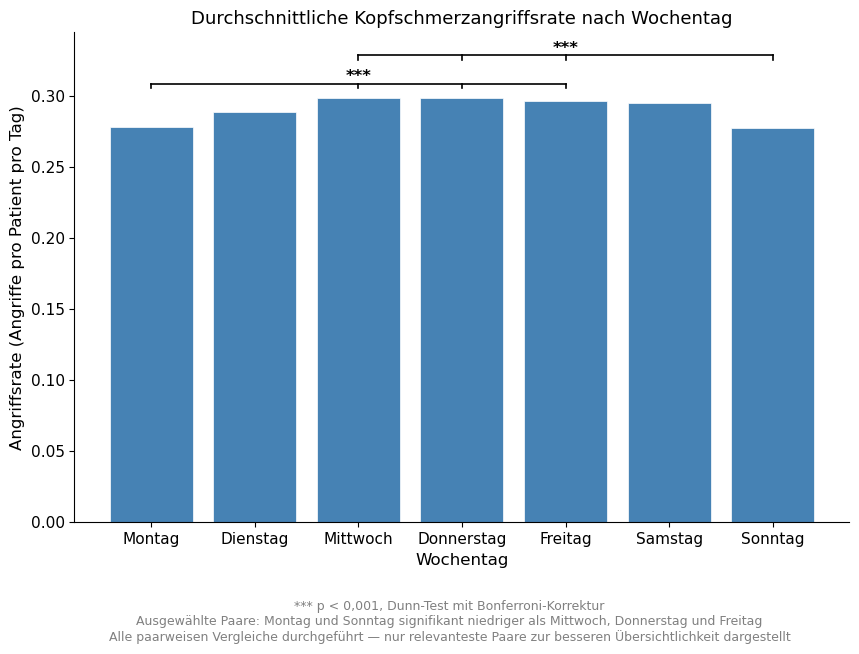

In [64]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.bar(days, weekly_mean.values,
       color='steelblue',
       edgecolor='white',
       linewidth=0.5)
tick = 0.003
gap = 0.020
# Mon vs Wed, Thu, Fri
y1 = max(weekly_mean.values) + 0.010
ax.plot([0, 4], [y1, y1], color='black', linewidth=1.2)
ax.plot([0, 0], [y1-tick, y1], color='black', linewidth=1.2)
ax.plot([2, 2], [y1-tick, y1], color='black', linewidth=1.2)
ax.plot([3, 3], [y1-tick, y1], color='black', linewidth=1.2)
ax.plot([4, 4], [y1-tick, y1], color='black', linewidth=1.2)
ax.text(2, y1+0.002, '***', ha='center', fontsize=12, fontweight='bold')
# Sun vs Wed, Thu, Fri
y2 = y1 + gap
ax.plot([2, 6], [y2, y2], color='black', linewidth=1.2)
ax.plot([2, 2], [y2-tick, y2], color='black', linewidth=1.2)
ax.plot([3, 3], [y2-tick, y2], color='black', linewidth=1.2)
ax.plot([4, 4], [y2-tick, y2], color='black', linewidth=1.2)
ax.plot([6, 6], [y2-tick, y2], color='black', linewidth=1.2)
ax.text(4, y2+0.002, '***', ha='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Wochentag', fontsize=12)
ax.set_ylabel('Angriffsrate (Angriffe pro Patient pro Tag)', fontsize=12)
ax.set_title('Durchschnittliche Kopfschmerzangriffsrate nach Wochentag', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)
fig.text(0.5, 0.01,
         '*** p < 0,001, Dunn-Test mit Bonferroni-Korrektur\n'
         'Ausgewählte Paare: Montag und Sonntag signifikant niedriger als Mittwoch, Donnerstag und Freitag\n'
         'Alle paarweisen Vergleiche durchgeführt — nur relevanteste Paare zur besseren Übersichtlichkeit dargestellt',
         ha='center', fontsize=9, color='gray')
plt.subplots_adjust(bottom=0.18)
plt.show()

In [65]:
monthly_mean = daily_rate.groupby(daily_rate.index.month).mean()
print(monthly_mean)

1     0.301326
2     0.306187
3     0.301029
4     0.298290
5     0.288505
6     0.284754
7     0.287900
8     0.279969
9     0.286241
10    0.287665
11    0.285787
12    0.277828
dtype: float64


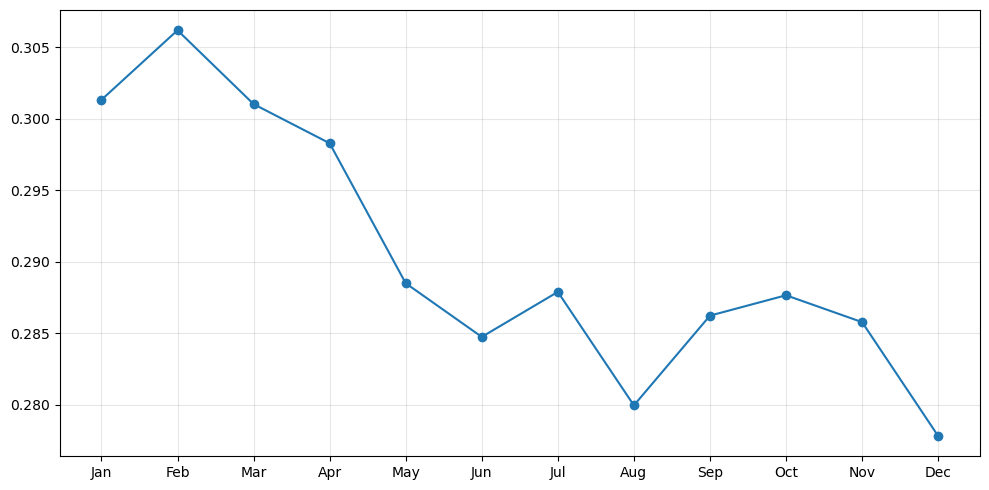

In [66]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
plt.plot(months, monthly_mean.values, marker='o')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
groups = [daily_rate[daily_rate.index.month == month].values 
          for month in range(1, 13)]

stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.4f}, p={p:.4f}")

Kruskal-Wallis H=100.4815, p=0.0000


In [68]:
dunn_monthly = sp.posthoc_dunn(
    [daily_rate[daily_rate.index.month == month].values 
     for month in range(1, 13)],
    p_adjust='bonferroni'
)

dunn_monthly.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dunn_monthly.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(dunn_monthly.round(4))

        Jan     Feb     Mar     Apr     May     Jun     Jul     Aug     Sep  \
Jan  1.0000  1.0000  1.0000  1.0000  0.5476  0.0040  0.1495  0.0000  0.4998   
Feb  1.0000  1.0000  1.0000  1.0000  0.0672  0.0003  0.0149  0.0000  0.0613   
Mar  1.0000  1.0000  1.0000  1.0000  0.0786  0.0003  0.0170  0.0000  0.0718   
Apr  1.0000  1.0000  1.0000  1.0000  1.0000  0.0364  0.8253  0.0003  1.0000   
May  0.5476  0.0672  0.0786  1.0000  1.0000  1.0000  1.0000  0.7586  1.0000   
Jun  0.0040  0.0003  0.0003  0.0364  1.0000  1.0000  1.0000  1.0000  1.0000   
Jul  0.1495  0.0149  0.0170  0.8253  1.0000  1.0000  1.0000  1.0000  1.0000   
Aug  0.0000  0.0000  0.0000  0.0003  0.7586  1.0000  1.0000  1.0000  0.9325   
Sep  0.4998  0.0613  0.0718  1.0000  1.0000  1.0000  1.0000  0.9325  1.0000   
Oct  1.0000  0.2633  0.3126  1.0000  1.0000  1.0000  1.0000  0.2140  1.0000   
Nov  0.5556  0.0695  0.0814  1.0000  1.0000  1.0000  1.0000  0.8438  1.0000   
Dec  0.0000  0.0000  0.0000  0.0000  0.0699  1.0000 

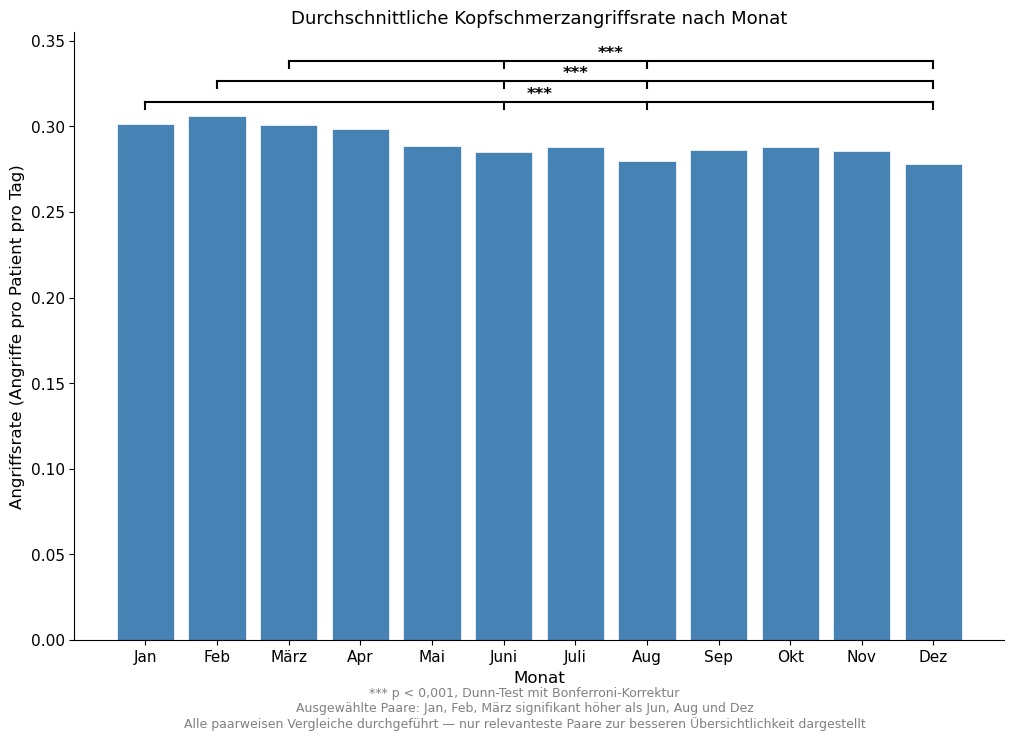

In [69]:
months = ['Jan', 'Feb', 'März', 'Apr', 'Mai', 'Juni',
          'Juli', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(months, monthly_mean.values,
       color='steelblue',
       edgecolor='white',
       linewidth=0.5)

base = max(monthly_mean.values) + 0.008
gap = 0.012
tick = 0.004

# Jan vs Jun, Aug, Dec
y1 = base
ax.plot([0, 11], [y1, y1], color='black', linewidth=1.5)
ax.plot([0, 0], [y1 - tick, y1], color='black', linewidth=1.5)   # Jan
ax.plot([5, 5], [y1 - tick, y1], color='black', linewidth=1.5)   # Jun
ax.plot([7, 7], [y1 - tick, y1], color='black', linewidth=1.5)   # Aug
ax.plot([11, 11], [y1 - tick, y1], color='black', linewidth=1.5) # Dec
ax.text(5.5, y1 + 0.002, '***', ha='center', fontsize=12, fontweight='bold')

# Feb vs Jun, Aug, Dec
y2 = y1 + gap
ax.plot([1, 11], [y2, y2], color='black', linewidth=1.5)
ax.plot([1, 1], [y2 - tick, y2], color='black', linewidth=1.5)   # Feb
ax.plot([5, 5], [y2 - tick, y2], color='black', linewidth=1.5)   # Jun
ax.plot([7, 7], [y2 - tick, y2], color='black', linewidth=1.5)   # Aug
ax.plot([11, 11], [y2 - tick, y2], color='black', linewidth=1.5) # Dec
ax.text(6, y2 + 0.002, '***', ha='center', fontsize=12, fontweight='bold')

# Mar vs Jun, Aug, Dec
y3 = y2 + gap
ax.plot([2, 11], [y3, y3], color='black', linewidth=1.5)
ax.plot([2, 2], [y3 - tick, y3], color='black', linewidth=1.5)   # Mar
ax.plot([5, 5], [y3 - tick, y3], color='black', linewidth=1.5)   # Jun
ax.plot([7, 7], [y3 - tick, y3], color='black', linewidth=1.5)   # Aug
ax.plot([11, 11], [y3 - tick, y3], color='black', linewidth=1.5) # Dec
ax.text(6.5, y3 + 0.002, '***', ha='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Monat', fontsize=12)
ax.set_ylabel('Angriffsrate (Angriffe pro Patient pro Tag)', fontsize=12)
ax.set_title('Durchschnittliche Kopfschmerzangriffsrate nach Monat', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

fig.text(0.5, 0.01,
         '*** p < 0,001, Dunn-Test mit Bonferroni-Korrektur\n'
         'Ausgewählte Paare: Jan, Feb, März signifikant höher als Jun, Aug und Dez\n'
         'Alle paarweisen Vergleiche durchgeführt — nur relevanteste Paare zur besseren Übersichtlichkeit dargestellt',
         ha='center', fontsize=9, color='gray')

plt.subplots_adjust(bottom=0.12)
plt.show()

In [70]:
# define seasons
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
              6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
              9: 'Herbst', 10: 'Herbst', 11: 'Herbst'}

# map seasons to daily rate
daily_rate_df = daily_rate.to_frame(name='rate')
daily_rate_df['season'] = daily_rate_df.index.month.map(season_map)

# average rate per season
season_order = ['Winter', 'Frühling', 'Sommer', 'Herbst']
seasonal_rate = daily_rate_df.groupby('season')['rate'].mean()
seasonal_rate = seasonal_rate.reindex(season_order)

print(seasonal_rate)

season
Winter      0.294770
Frühling    0.295916
Sommer      0.284202
Herbst      0.286577
Name: rate, dtype: float64


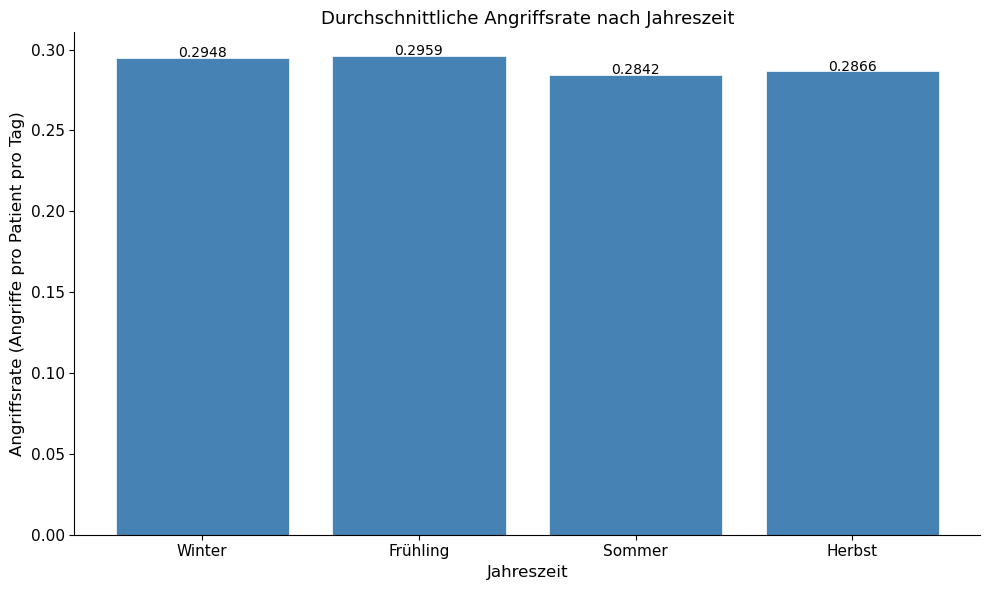

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(season_order, seasonal_rate.values,
              color='steelblue',
              edgecolor='white',
              linewidth=0.5)

# add value labels on top of bars
for bar, val in zip(bars, seasonal_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{val:.4f}',
            ha='center', fontsize=10)

ax.set_xlabel('Jahreszeit', fontsize=12)
ax.set_ylabel('Angriffsrate (Angriffe pro Patient pro Tag)', fontsize=12)
ax.set_title('Durchschnittliche Angriffsrate nach Jahreszeit', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)


plt.tight_layout()
plt.show()

In [72]:
yearly_mean = daily_rate.groupby(daily_rate.index.year).mean()
print(yearly_mean)

2021    0.334093
2022    0.285524
2023    0.264007
2024    0.274356
2025    0.293838
dtype: float64


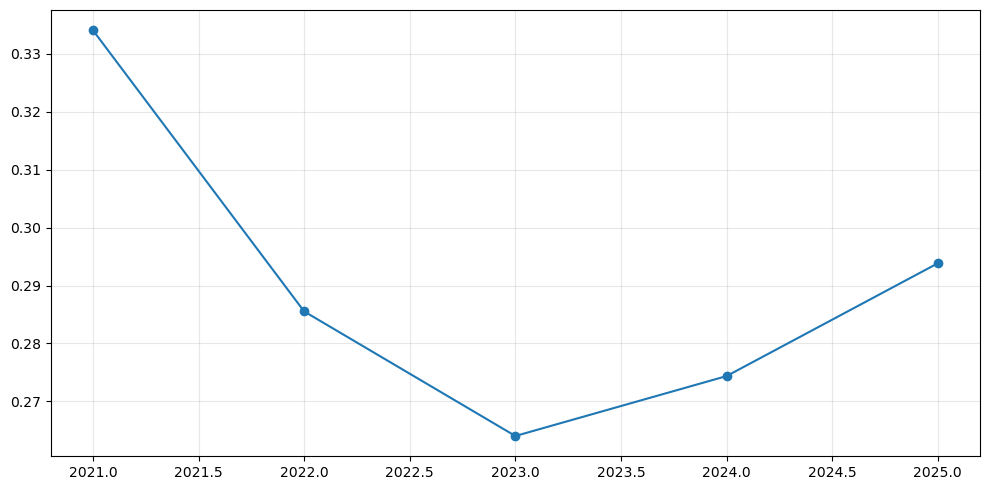

In [73]:
years = [2021, 2022, 2023, 2024, 2025]

plt.figure(figsize=(10, 5))
plt.plot(years, yearly_mean.values, marker='o')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
pip install pymannkendall

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple
  Using cached pymannkendall-1.4.3-py3-none-any.whl.metadata (14 kB)
Using cached pymannkendall-1.4.3-py3-none-any.whl (12 kB)
Note: you may need to restart the kernel to use updated packages.


In [75]:
import pymannkendall as mk

result = mk.original_test(yearly_mean.values)
print(f"Trend: {result.trend}")
print(f"p-value: {result.p:.4f}")
print(f"Tau: {result.Tau:.4f}")

Trend: no trend
p-value: 0.8065
Tau: -0.2000


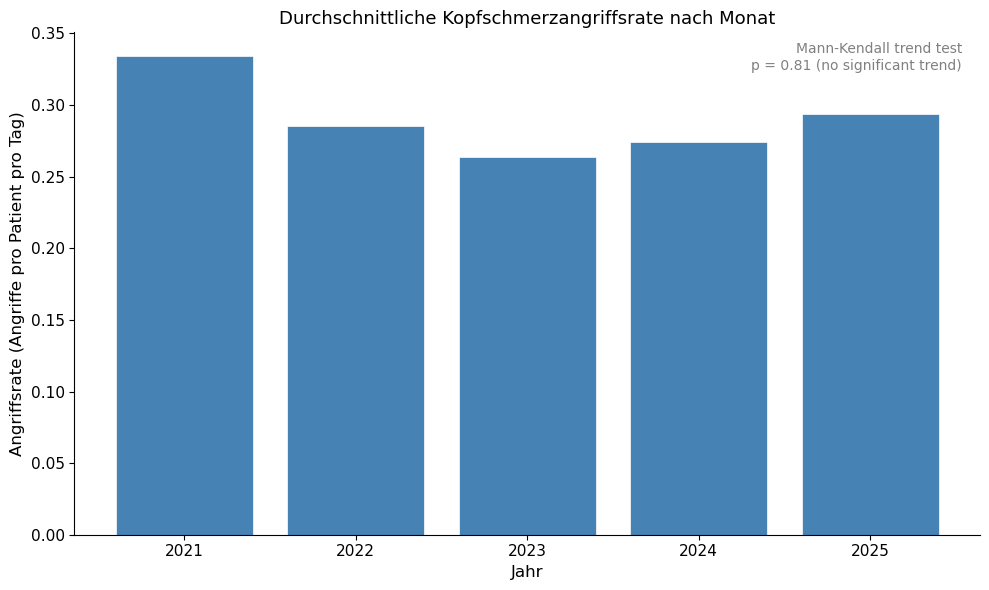

In [76]:
years = [2021, 2022, 2023, 2024, 2025]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(years, yearly_mean.values,
       color='steelblue',
       edgecolor='white',
       linewidth=0.5)

# add Mann-Kendall result as text on plot
ax.text(0.98, 0.98,
        'Mann-Kendall trend test\np = 0.81 (no significant trend)',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=10, color='gray')

ax.set_xlabel('Jahr', fontsize=12)
ax.set_ylabel('Angriffsrate (Angriffe pro Patient pro Tag)', fontsize=12)
ax.set_title('Durchschnittliche Kopfschmerzangriffsrate nach Monat', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(years)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

In [77]:
# rename current results
weekly_mean_all = weekly_mean.copy()

monthly_mean_all = monthly_mean.copy()

yearly_mean_all = yearly_mean.copy()

daily_rate_all = daily_rate.copy()

In [78]:
# Step 1 - recreate split
attacks_per_month = (df.groupby(['patient_info_id', 'year', 'month'])
                      .size()
                      .reset_index(name='n_attacks'))

avg_attacks = (attacks_per_month.groupby('patient_info_id')['n_attacks']
                                .mean())

chronic_patients = avg_attacks[avg_attacks >= 15].index
episodic_patients = avg_attacks[avg_attacks < 15].index

# Step 2 - create and filter df_episodic
df_episodic = df[df['patient_info_id'].isin(episodic_patients)]
df_episodic = df_episodic[~df_episodic['year'].isin([2020, 2026])]

# Step 3 - complete date range
all_days_ep = pd.date_range(
    start=df_episodic['attack_time'].min(),
    end=df_episodic['attack_time'].max(),
    freq='D'
)

# Step 4 - daily attacks
daily_attacks_ep = df_episodic.groupby('attack_time').size()
daily_attacks_ep.index = pd.to_datetime(daily_attacks_ep.index)
daily_attacks_ep = daily_attacks_ep.reindex(all_days_ep, fill_value=0)

# Step 5 - daily participants loop
daily_participants_ep = []
for day in all_days_ep:
    active = (
        (df_episodic['first_app_entry'] <= day) &
        (df_episodic['last_app_entry'] >= day)
    )
    n_active = df_episodic.loc[active, 'patient_info_id'].nunique()
    daily_participants_ep.append(n_active)

daily_participants_ep = pd.Series(daily_participants_ep, index=all_days_ep)
daily_participants_ep.index = pd.to_datetime(daily_participants_ep.index)

# Step 6 - daily rate
daily_rate_ep = daily_attacks_ep / daily_participants_ep

# Step 7 - weekly monthly yearly
weekly_mean_ep = daily_rate_ep.groupby(daily_rate_ep.index.dayofweek).mean()
weekly_std_ep = daily_rate_ep.groupby(daily_rate_ep.index.dayofweek).std()

monthly_mean_ep = daily_rate_ep.groupby(daily_rate_ep.index.month).mean()
monthly_std_ep = daily_rate_ep.groupby(daily_rate_ep.index.month).std()

yearly_mean_ep = daily_rate_ep.groupby(daily_rate_ep.index.year).mean()
yearly_std_ep = daily_rate_ep.groupby(daily_rate_ep.index.year).std()

print("Weekly mean episodic:")
print(weekly_mean_ep)
print("\nMonthly mean episodic:")
print(monthly_mean_ep)
print("\nYearly mean episodic:")
print(yearly_mean_ep)

Weekly mean episodic:
0    0.203118
1    0.213991
2    0.224968
3    0.225873
4    0.223941
5    0.223505
6    0.204172
dtype: float64

Monthly mean episodic:
1     0.229041
2     0.232092
3     0.223503
4     0.222801
5     0.217144
6     0.214343
7     0.216143
8     0.208480
9     0.213598
10    0.213390
11    0.211592
12    0.203953
dtype: float64

Yearly mean episodic:
2021    0.258936
2022    0.221664
2023    0.200476
2024    0.200243
2025    0.204109
dtype: float64


In [79]:
from scipy import stats
import scikit_posthocs as sp
import pymannkendall as mk

# ── Weekly ────────────────────────────────────────────
groups_weekly_ep = [daily_rate_ep[daily_rate_ep.index.dayofweek == day].values 
                    for day in range(7)]
stat_w, p_w = stats.kruskal(*groups_weekly_ep)
print(f"Weekly Kruskal-Wallis H={stat_w:.4f}, p={p_w:.4f}")

# ── Monthly ───────────────────────────────────────────
groups_monthly_ep = [daily_rate_ep[daily_rate_ep.index.month == month].values 
                     for month in range(1, 13)]
stat_m, p_m = stats.kruskal(*groups_monthly_ep)
print(f"Monthly Kruskal-Wallis H={stat_m:.4f}, p={p_m:.4f}")

# ── Yearly ────────────────────────────────────────────
result_ep = mk.original_test(yearly_mean_ep.values)
print(f"Yearly Trend: {result_ep.trend}")
print(f"Yearly p-value: {result_ep.p:.4f}")
print(f"Yearly Tau: {result_ep.Tau:.4f}")

Weekly Kruskal-Wallis H=235.0084, p=0.0000
Monthly Kruskal-Wallis H=106.9290, p=0.0000
Yearly Trend: no trend
Yearly p-value: 0.2207
Yearly Tau: -0.6000


In [80]:
# ── Weekly Dunn ───────────────────────────────────────
dunn_weekly_ep = sp.posthoc_dunn(
    [daily_rate_ep[daily_rate_ep.index.dayofweek == day].values 
     for day in range(7)],
    p_adjust='bonferroni'
)

dunn_weekly_ep.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dunn_weekly_ep.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print("Weekly Dunn test episodic:")
print(dunn_weekly_ep.round(4))

# ── Monthly Dunn ──────────────────────────────────────
dunn_monthly_ep = sp.posthoc_dunn(
    [daily_rate_ep[daily_rate_ep.index.month == month].values 
     for month in range(1, 13)],
    p_adjust='bonferroni'
)

dunn_monthly_ep.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dunn_monthly_ep.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("\nMonthly Dunn test episodic:")
print(dunn_monthly_ep.round(4))

Weekly Dunn test episodic:
     Mon     Tue     Wed     Thu     Fri     Sat  Sun
Mon  1.0  0.0000  0.0000  0.0000  0.0000  0.0000  1.0
Tue  0.0  1.0000  0.0001  0.0002  0.0028  0.0006  0.0
Wed  0.0  0.0001  1.0000  1.0000  1.0000  1.0000  0.0
Thu  0.0  0.0002  1.0000  1.0000  1.0000  1.0000  0.0
Fri  0.0  0.0028  1.0000  1.0000  1.0000  1.0000  0.0
Sat  0.0  0.0006  1.0000  1.0000  1.0000  1.0000  0.0
Sun  1.0  0.0000  0.0000  0.0000  0.0000  0.0000  1.0

Monthly Dunn test episodic:
        Jan     Feb     Mar     Apr     May     Jun     Jul     Aug     Sep  \
Jan  1.0000  1.0000  1.0000  1.0000  0.3442  0.0073  0.0732  0.0000  0.3900   
Feb  1.0000  1.0000  1.0000  1.0000  0.0743  0.0011  0.0135  0.0000  0.0863   
Mar  1.0000  1.0000  1.0000  1.0000  0.2514  0.0048  0.0512  0.0000  0.2867   
Apr  1.0000  1.0000  1.0000  1.0000  1.0000  0.3011  1.0000  0.0027  1.0000   
May  0.3442  0.0743  0.2514  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000   
Jun  0.0073  0.0011  0.0048  0.3011  1

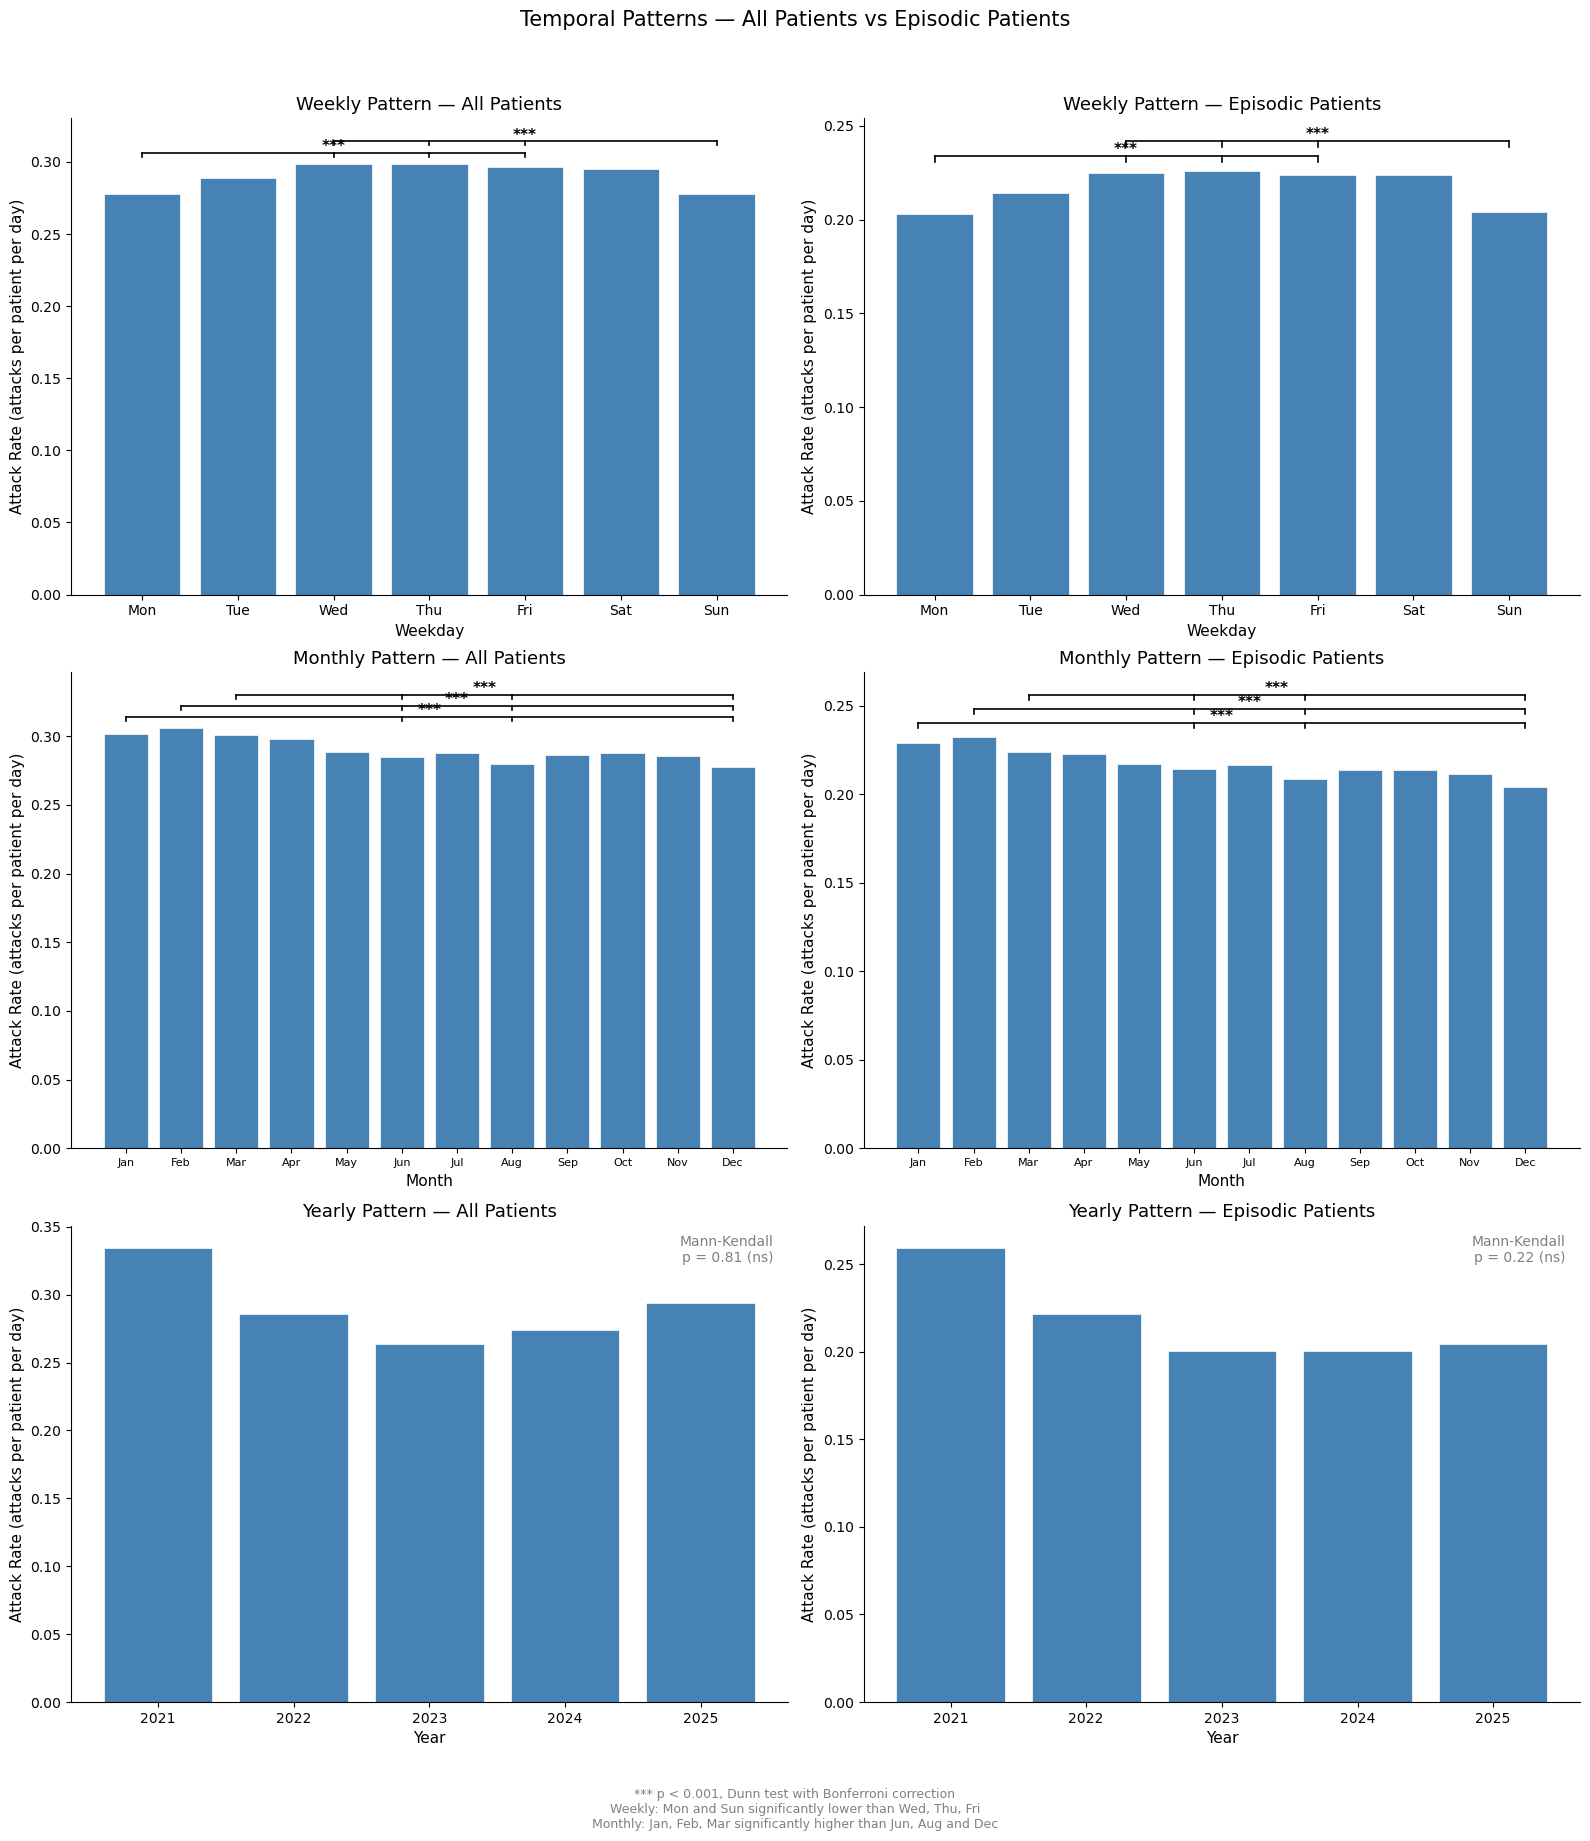

In [81]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
years = [2021, 2022, 2023, 2024, 2025]

tick = 0.003
gap = 0.008

# ── Weekly All ────────────────────────────────────────
axes[0, 0].bar(days, weekly_mean_all.values,
               color='steelblue', edgecolor='white', linewidth=0.5)

# Mon vs Wed, Thu, Fri
y1 = max(weekly_mean_all.values) + 0.008
axes[0, 0].plot([0, 4], [y1, y1], color='black', linewidth=1.2)
axes[0, 0].plot([0, 0], [y1-tick, y1], color='black', linewidth=1.2)  # Mon
axes[0, 0].plot([2, 2], [y1-tick, y1], color='black', linewidth=1.2)  # Wed
axes[0, 0].plot([3, 3], [y1-tick, y1], color='black', linewidth=1.2)  # Thu
axes[0, 0].plot([4, 4], [y1-tick, y1], color='black', linewidth=1.2)  # Fri
axes[0, 0].text(2, y1+0.001, '***', ha='center', fontsize=11, fontweight='bold')

# Sun vs Wed, Thu, Fri
y2 = y1 + gap
axes[0, 0].plot([2, 6], [y2, y2], color='black', linewidth=1.2)
axes[0, 0].plot([2, 2], [y2-tick, y2], color='black', linewidth=1.2)  # Wed
axes[0, 0].plot([3, 3], [y2-tick, y2], color='black', linewidth=1.2)  # Thu
axes[0, 0].plot([4, 4], [y2-tick, y2], color='black', linewidth=1.2)  # Fri
axes[0, 0].plot([6, 6], [y2-tick, y2], color='black', linewidth=1.2)  # Sun
axes[0, 0].text(4, y2+0.001, '***', ha='center', fontsize=11, fontweight='bold')

axes[0, 0].set_title('Weekly Pattern — All Patients', fontsize=13)
axes[0, 0].set_xlabel('Weekday', fontsize=11)
axes[0, 0].set_ylabel('Attack Rate (attacks per patient per day)', fontsize=11)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# ── Weekly Episodic ───────────────────────────────────
axes[0, 1].bar(days, weekly_mean_ep.values,
               color='steelblue', edgecolor='white', linewidth=0.5)

# Mon vs Wed, Thu, Fri
y1 = max(weekly_mean_ep.values) + 0.008
axes[0, 1].plot([0, 4], [y1, y1], color='black', linewidth=1.2)
axes[0, 1].plot([0, 0], [y1-tick, y1], color='black', linewidth=1.2)  # Mon
axes[0, 1].plot([2, 2], [y1-tick, y1], color='black', linewidth=1.2)  # Wed
axes[0, 1].plot([3, 3], [y1-tick, y1], color='black', linewidth=1.2)  # Thu
axes[0, 1].plot([4, 4], [y1-tick, y1], color='black', linewidth=1.2)  # Fri
axes[0, 1].text(2, y1+0.001, '***', ha='center', fontsize=11, fontweight='bold')

# Sun vs Wed, Thu, Fri
y2 = y1 + gap
axes[0, 1].plot([2, 6], [y2, y2], color='black', linewidth=1.2)
axes[0, 1].plot([2, 2], [y2-tick, y2], color='black', linewidth=1.2)  # Wed
axes[0, 1].plot([3, 3], [y2-tick, y2], color='black', linewidth=1.2)  # Thu
axes[0, 1].plot([4, 4], [y2-tick, y2], color='black', linewidth=1.2)  # Fri
axes[0, 1].plot([6, 6], [y2-tick, y2], color='black', linewidth=1.2)  # Sun
axes[0, 1].text(4, y2+0.001, '***', ha='center', fontsize=11, fontweight='bold')

axes[0, 1].set_title('Weekly Pattern — Episodic Patients', fontsize=13)
axes[0, 1].set_xlabel('Weekday', fontsize=11)
axes[0, 1].set_ylabel('Attack Rate (attacks per patient per day)', fontsize=11)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# ── Monthly All ───────────────────────────────────────
axes[1, 0].bar(months, monthly_mean_all.values,
               color='steelblue', edgecolor='white', linewidth=0.5)

y1 = max(monthly_mean_all.values) + 0.008
axes[1, 0].plot([0, 11], [y1, y1], color='black', linewidth=1.2)
axes[1, 0].plot([0, 0], [y1-tick, y1], color='black', linewidth=1.2)
axes[1, 0].plot([5, 5], [y1-tick, y1], color='black', linewidth=1.2)
axes[1, 0].plot([7, 7], [y1-tick, y1], color='black', linewidth=1.2)
axes[1, 0].plot([11, 11], [y1-tick, y1], color='black', linewidth=1.2)
axes[1, 0].text(5.5, y1+0.001, '***', ha='center', fontsize=11, fontweight='bold')

y2 = y1 + gap
axes[1, 0].plot([1, 11], [y2, y2], color='black', linewidth=1.2)
axes[1, 0].plot([1, 1], [y2-tick, y2], color='black', linewidth=1.2)
axes[1, 0].plot([5, 5], [y2-tick, y2], color='black', linewidth=1.2)
axes[1, 0].plot([7, 7], [y2-tick, y2], color='black', linewidth=1.2)
axes[1, 0].plot([11, 11], [y2-tick, y2], color='black', linewidth=1.2)
axes[1, 0].text(6, y2+0.001, '***', ha='center', fontsize=11, fontweight='bold')

y3 = y2 + gap
axes[1, 0].plot([2, 11], [y3, y3], color='black', linewidth=1.2)
axes[1, 0].plot([2, 2], [y3-tick, y3], color='black', linewidth=1.2)
axes[1, 0].plot([5, 5], [y3-tick, y3], color='black', linewidth=1.2)
axes[1, 0].plot([7, 7], [y3-tick, y3], color='black', linewidth=1.2)
axes[1, 0].plot([11, 11], [y3-tick, y3], color='black', linewidth=1.2)
axes[1, 0].text(6.5, y3+0.001, '***', ha='center', fontsize=11, fontweight='bold')

axes[1, 0].set_title('Monthly Pattern — All Patients', fontsize=13)
axes[1, 0].set_xlabel('Month', fontsize=11)
axes[1, 0].set_ylabel('Attack Rate (attacks per patient per day)', fontsize=11)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].tick_params(axis='x', labelsize=8)

# ── Monthly Episodic ──────────────────────────────────
axes[1, 1].bar(months, monthly_mean_ep.values,
               color='steelblue', edgecolor='white', linewidth=0.5)

y1 = max(monthly_mean_ep.values) + 0.008
axes[1, 1].plot([0, 11], [y1, y1], color='black', linewidth=1.2)
axes[1, 1].plot([0, 0], [y1-tick, y1], color='black', linewidth=1.2)
axes[1, 1].plot([5, 5], [y1-tick, y1], color='black', linewidth=1.2)
axes[1, 1].plot([7, 7], [y1-tick, y1], color='black', linewidth=1.2)
axes[1, 1].plot([11, 11], [y1-tick, y1], color='black', linewidth=1.2)
axes[1, 1].text(5.5, y1+0.001, '***', ha='center', fontsize=11, fontweight='bold')

y2 = y1 + gap
axes[1, 1].plot([1, 11], [y2, y2], color='black', linewidth=1.2)
axes[1, 1].plot([1, 1], [y2-tick, y2], color='black', linewidth=1.2)
axes[1, 1].plot([5, 5], [y2-tick, y2], color='black', linewidth=1.2)
axes[1, 1].plot([7, 7], [y2-tick, y2], color='black', linewidth=1.2)
axes[1, 1].plot([11, 11], [y2-tick, y2], color='black', linewidth=1.2)
axes[1, 1].text(6, y2+0.001, '***', ha='center', fontsize=11, fontweight='bold')

y3 = y2 + gap
axes[1, 1].plot([2, 11], [y3, y3], color='black', linewidth=1.2)
axes[1, 1].plot([2, 2], [y3-tick, y3], color='black', linewidth=1.2)
axes[1, 1].plot([5, 5], [y3-tick, y3], color='black', linewidth=1.2)
axes[1, 1].plot([7, 7], [y3-tick, y3], color='black', linewidth=1.2)
axes[1, 1].plot([11, 11], [y3-tick, y3], color='black', linewidth=1.2)
axes[1, 1].text(6.5, y3+0.001, '***', ha='center', fontsize=11, fontweight='bold')

axes[1, 1].set_title('Monthly Pattern — Episodic Patients', fontsize=13)
axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Attack Rate (attacks per patient per day)', fontsize=11)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].tick_params(axis='x', labelsize=8)

# ── Yearly All ────────────────────────────────────────
axes[2, 0].bar(years, yearly_mean_all.values,
               color='steelblue', edgecolor='white', linewidth=0.5)
axes[2, 0].set_title('Yearly Pattern — All Patients', fontsize=13)
axes[2, 0].set_xlabel('Year', fontsize=11)
axes[2, 0].set_ylabel('Attack Rate (attacks per patient per day)', fontsize=11)
axes[2, 0].spines['top'].set_visible(False)
axes[2, 0].spines['right'].set_visible(False)
axes[2, 0].set_xticks(years)
axes[2, 0].text(0.98, 0.98, 'Mann-Kendall\np = 0.81 (ns)',
                transform=axes[2, 0].transAxes,
                ha='right', va='top', fontsize=10, color='gray')

# ── Yearly Episodic ───────────────────────────────────
axes[2, 1].bar(years, yearly_mean_ep.values,
               color='steelblue', edgecolor='white', linewidth=0.5)
axes[2, 1].set_title('Yearly Pattern — Episodic Patients', fontsize=13)
axes[2, 1].set_xlabel('Year', fontsize=11)
axes[2, 1].set_ylabel('Attack Rate (attacks per patient per day)', fontsize=11)
axes[2, 1].spines['top'].set_visible(False)
axes[2, 1].spines['right'].set_visible(False)
axes[2, 1].set_xticks(years)
axes[2, 1].text(0.98, 0.98, 'Mann-Kendall\np = 0.22 (ns)',
                transform=axes[2, 1].transAxes,
                ha='right', va='top', fontsize=10, color='gray')

# note
fig.text(0.5, 0.01,
         '*** p < 0.001, Dunn test with Bonferroni correction\n'
         'Weekly: Mon and Sun significantly lower than Wed, Thu, Fri\n'
         'Monthly: Jan, Feb, Mar significantly higher than Jun, Aug and Dec',
         ha='center', fontsize=9, color='gray')

plt.suptitle('Temporal Patterns — All Patients vs Episodic Patients',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

In [82]:
#decomposition

In [83]:
weekly_rate = daily_rate.resample('W').mean()
print(f"Total weeks: {len(weekly_rate)}")
print(f"Date range: {weekly_rate.index[0]} to {weekly_rate.index[-1]}")
print(weekly_rate.head(10))

Total weeks: 262
Date range: 2021-01-03 00:00:00 to 2026-01-04 00:00:00
2021-01-03    0.336257
2021-01-10    0.359766
2021-01-17    0.366016
2021-01-24    0.341130
2021-01-31    0.400440
2021-02-07    0.376990
2021-02-14    0.382153
2021-02-21    0.378321
2021-02-28    0.376172
2021-03-07    0.361030
Freq: W-SUN, dtype: float64


In [84]:
print(daily_rate.index[-5:])
print(daily_rate['2025-12-28':].head(10))

DatetimeIndex(['2025-12-27', '2025-12-28', '2025-12-29', '2025-12-30',
               '2025-12-31'],
              dtype='datetime64[ns]', freq='D')
2025-12-28    0.281556
2025-12-29    0.296261
2025-12-30    0.306084
2025-12-31    0.311372
Freq: D, dtype: float64


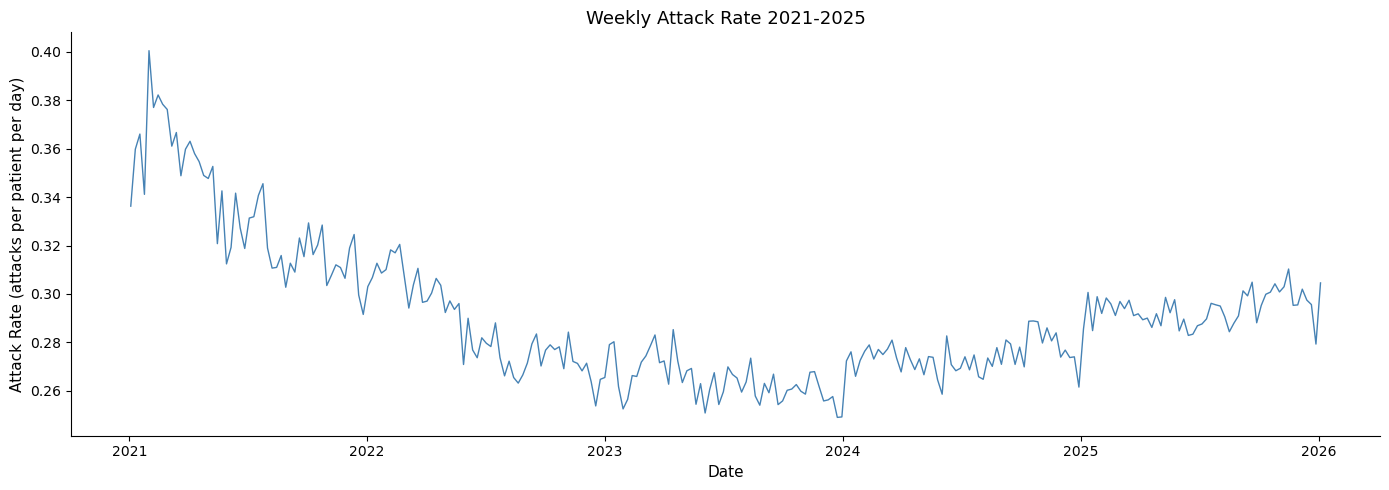

In [85]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(weekly_rate.index, weekly_rate.values,
        color='steelblue', linewidth=1)
ax.set_title('Weekly Attack Rate 2021-2025', fontsize=13)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Attack Rate (attacks per patient per day)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

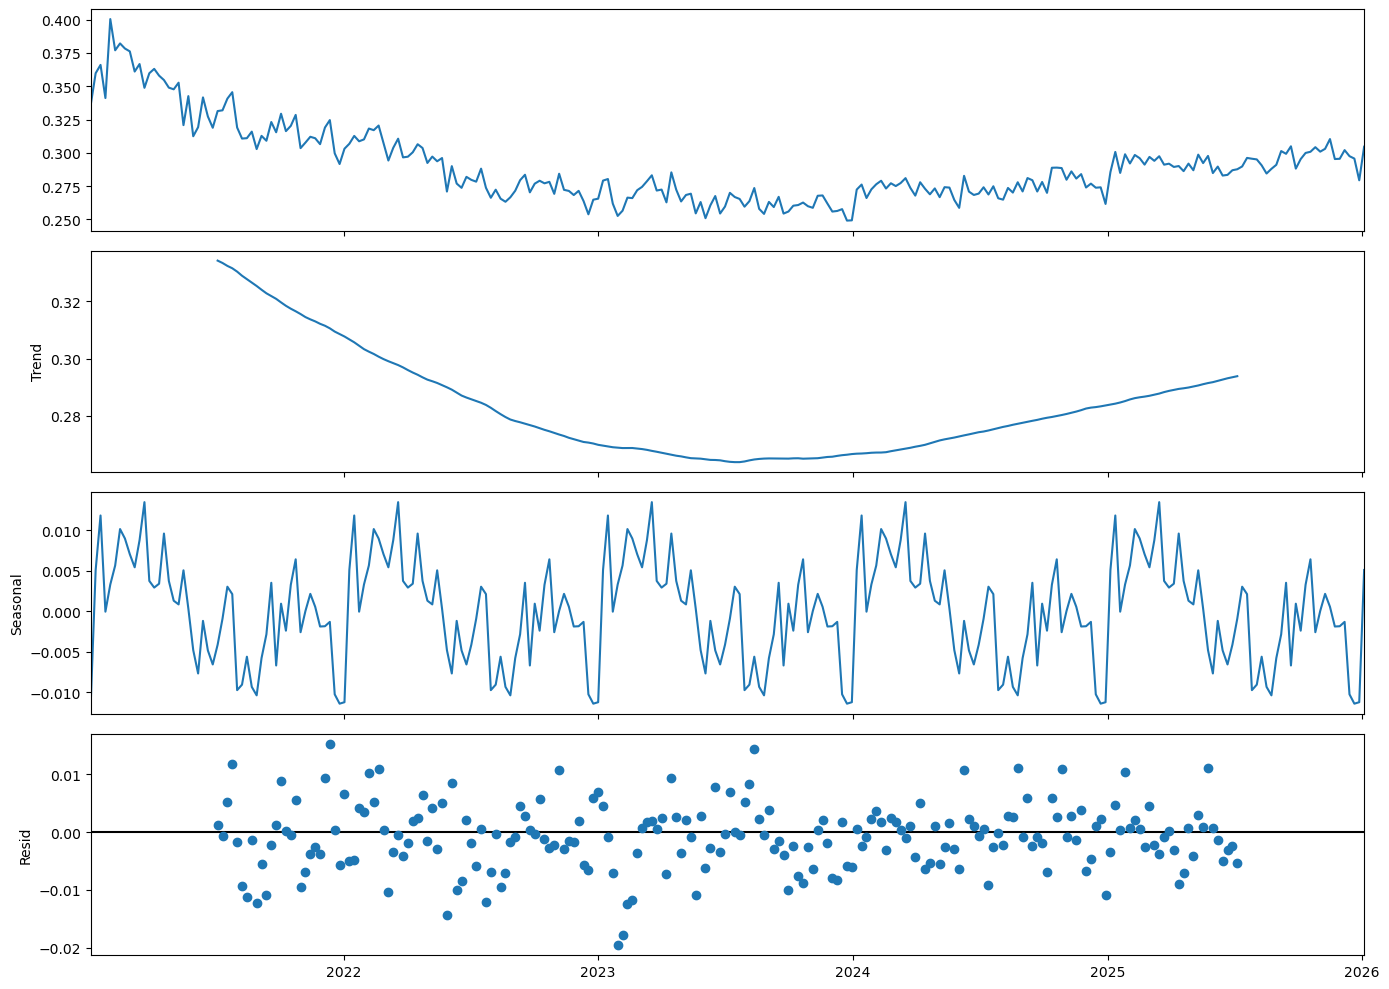

In [86]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(weekly_rate, 
                                   model='additive',
                                   period=52)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

In [87]:
train = weekly_rate[weekly_rate.index.year <= 2024]
test  = weekly_rate[weekly_rate.index.year == 2025]

print(f"Train weeks: {len(train)}")
print(f"Test weeks: {len(test)}")

Train weeks: 209
Test weeks: 52


In [88]:
# 1 — Last value
last_value = pd.Series(
    [train.iloc[-1]] * len(test),
    index=test.index)

# 2 — Train average
train_avg = pd.Series(
    [train.mean()] * len(test),
    index=test.index)

# 3 — Moving average (last 4 weeks)
moving_avg = pd.Series(
    [train.iloc[-4:].mean()] * len(test),
    index=test.index)

# 4 — Last season (same week last year)
last_season = train.iloc[-52:].values
last_season = pd.Series(last_season, index=test.index)

print("Last value:", last_value.iloc[0].round(4))
print("Train average:", train_avg.iloc[0].round(4))
print("Moving average:", moving_avg.iloc[0].round(4))
print("Last season head:", last_season.head(3).round(4).values)

Last value: 0.2616
Train average: 0.2896
Moving average: 0.2716
Last season head: [0.2724 0.2761 0.266 ]


In [89]:
import numpy as np

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted)**2))

def smape(actual, predicted):
    return np.mean(2 * np.abs(actual - predicted) / 
                   (np.abs(actual) + np.abs(predicted))) * 100

# evaluate all baselines
actual = test.values

results = {
    'Last Value':    [mae(actual, last_value.values),
                      rmse(actual, last_value.values),
                      smape(actual, last_value.values)],
    'Train Average': [mae(actual, train_avg.values),
                      rmse(actual, train_avg.values),
                      smape(actual, train_avg.values)],
    'Moving Average':[mae(actual, moving_avg.values),
                      rmse(actual, moving_avg.values),
                      smape(actual, moving_avg.values)],
    'Last Season':   [mae(actual, last_season.values),
                      rmse(actual, last_season.values),
                      smape(actual, last_season.values)]
}

results_df = pd.DataFrame(results, 
                           index=['MAE', 'RMSE', 'sMAPE (%)'])

print(results_df.round(4))

           Last Value  Train Average  Moving Average  Last Season
MAE            0.0321         0.0062          0.0221       0.0193
RMSE           0.0327         0.0076          0.0230       0.0202
sMAPE (%)     11.5319         2.1131          7.7927       6.8014


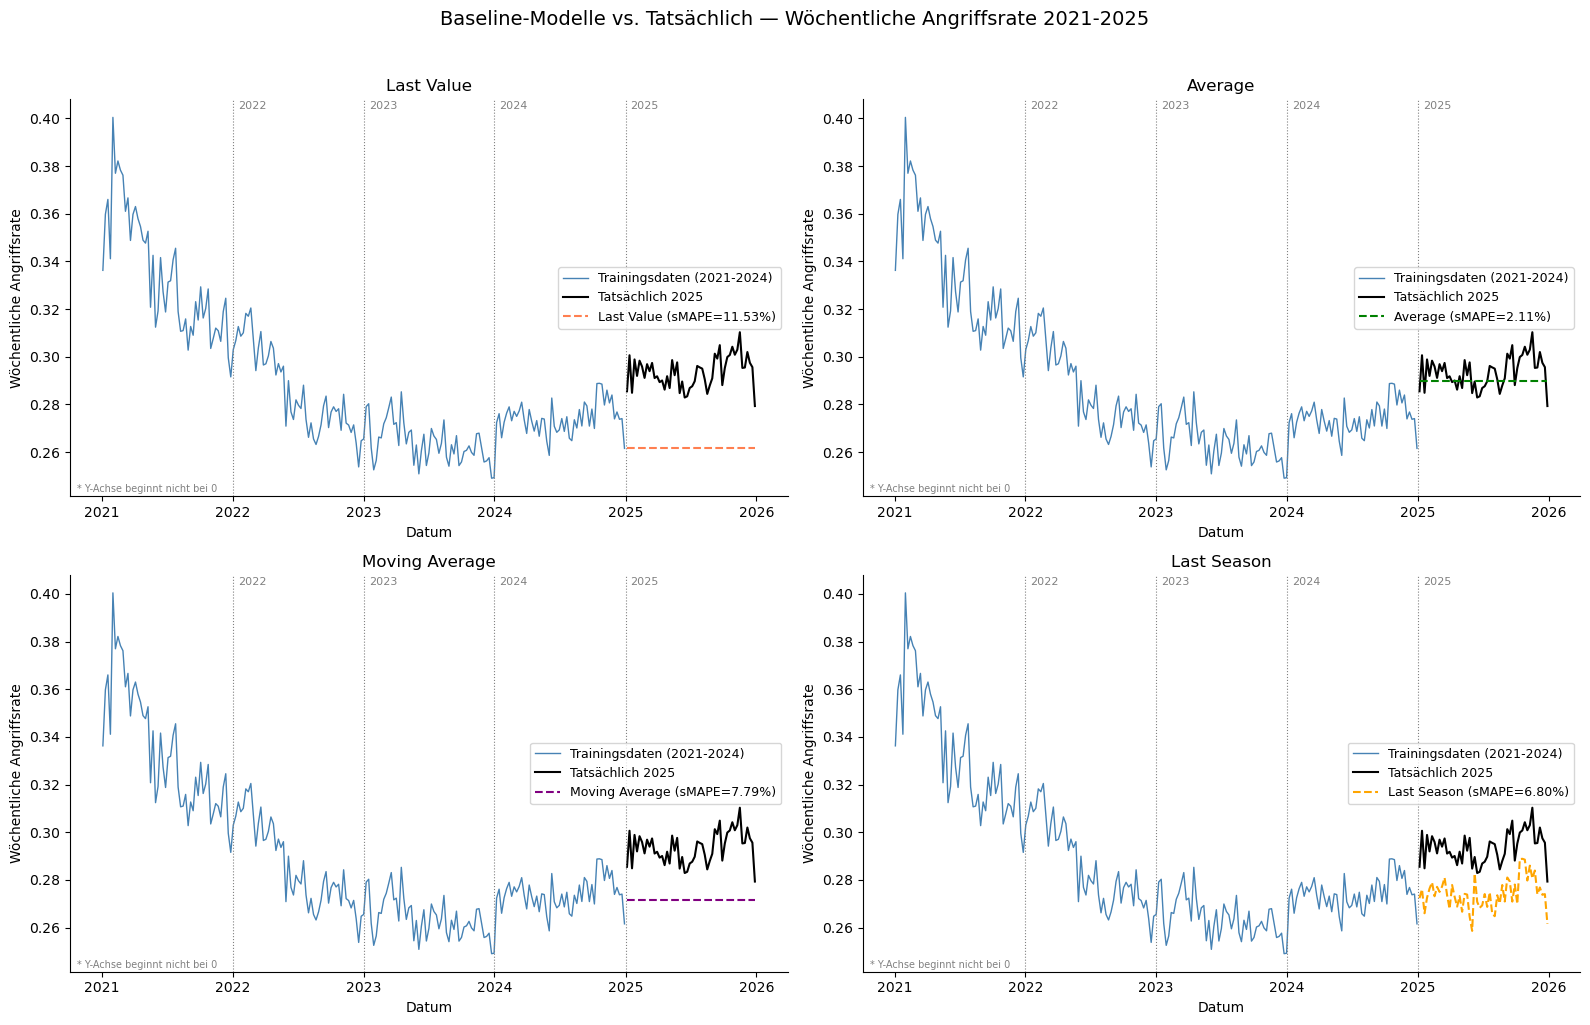

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

baselines = [
    ('Last Value', last_value, 'coral'),
    ('Average', train_avg, 'green'),
    ('Moving Average', moving_avg, 'purple'),
    ('Last Season', last_season, 'orange')
]

for idx, (name, forecast, color) in enumerate(baselines):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    # Trainingsdaten
    ax.plot(train.index, train.values,
            color='steelblue', linewidth=1,
            label='Trainingsdaten (2021-2024)')

    # Tatsächliche 2025
    ax.plot(test.index, test.values,
            color='black', linewidth=1.5,
            label='Tatsächlich 2025')

    # Baseline-Prognose
    ax.plot(test.index, forecast.values,
            color=color, linewidth=1.5,
            linestyle='--',
            label=f'{name} (sMAPE={smape(actual, forecast.values):.2f}%)')

    # Vertikale Linien
    for year in [2022, 2023, 2024, 2025]:
        ax.axvline(x=pd.Timestamp(f'{year}-01-01'),
                   color='gray', linestyle=':', linewidth=0.8)
        ax.text(pd.Timestamp(f'{year}-01-15'),
                ax.get_ylim()[1] * 0.99,
                str(year), fontsize=8, color='gray')

    ax.set_title(f'{name}', fontsize=12)
    ax.set_xlabel('Datum', fontsize=10)
    ax.set_ylabel('Wöchentliche Angriffsrate', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.annotate('* Y-Achse beginnt nicht bei 0',
                xy=(0.01, 0.01),
                xycoords='axes fraction',
                fontsize=7, color='gray')

plt.suptitle('Baseline-Modelle vs. Tatsächlich — Wöchentliche Angriffsrate 2021-2025',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [91]:
pip install pmdarima

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple
  Using cached pmdarima-2.1.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.5 kB)
Using cached pmdarima-2.1.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (689 kB)
Note: you may need to restart the kernel to use updated packages.


In [100]:
# No need to run this cell as it will take a lot of time to do all the combinations and optimise these.
from pmdarima import auto_arima

model_weekly = auto_arima(train,
                          seasonal=True,
                          m=52,              # yearly seasonality
                          stepwise=True,
                          trace=True,
                          error_action='ignore',
                          suppress_warnings=True)

print(model_weekly.summary())

Performing stepwise search to minimize aic


KeyboardInterrupt: 

In [92]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_weekly = SARIMAX(train,
                       order=(0, 1, 1),
                       seasonal_order=(0, 0, 1, 52))

result_weekly = model_weekly.fit(disp=False)
print(result_weekly.summary())

/opt/conda/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  209
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 52)   Log Likelihood                 677.683
Date:                            Tue, 30 Jun 2026   AIC                          -1349.367
Time:                                    05:48:51   BIC                          -1339.354
Sample:                                01-03-2021   HQIC                         -1345.318
                                     - 12-29-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5362      0.066     -8.114      0.000      -0.666      -0.407
ma.S.L52       0.2930      0.083   

In [93]:
forecast_arima = result_weekly.forecast(steps=52)
forecast_arima = pd.Series(forecast_arima.values, index=test.index)

mae_arima   = mae(test.values, forecast_arima.values)
rmse_arima  = rmse(test.values, forecast_arima.values)
smape_arima = smape(test.values, forecast_arima.values)

print(f"ARIMA MAE:   {mae_arima:.4f}")
print(f"ARIMA RMSE:  {rmse_arima:.4f}")
print(f"ARIMA sMAPE: {smape_arima:.2f}%")

ARIMA MAE:   0.0185
ARIMA RMSE:  0.0194
ARIMA sMAPE: 6.49%


In [94]:
forecast_arima = result_weekly.forecast(steps=52)
forecast_arima = pd.Series(forecast_arima.values, index=test.index)

mae_arima   = mae(test.values, forecast_arima.values)
rmse_arima  = rmse(test.values, forecast_arima.values)
smape_arima = smape(test.values, forecast_arima.values)

print(f"ARIMA MAE:   {mae_arima:.4f}")
print(f"ARIMA RMSE:  {rmse_arima:.4f}")
print(f"ARIMA sMAPE: {smape_arima:.2f}%")

# comparison table
comparison_arima = pd.DataFrame({
    'Date': test.index,
    'Actual': test.values.round(4),
    'Forecast': forecast_arima.values.round(4),
    'Difference': (test.values - forecast_arima.values).round(4),
    'Error %': (abs(test.values - forecast_arima.values) / test.values * 100).round(2)
})
comparison_arima = comparison_arima.set_index('Date')

print("\nWeekly Comparison — Actual vs ARIMA Forecast 2025:")
print(comparison_arima.to_string())
print(f"\nMean difference: {comparison_arima['Difference'].mean():.4f}")
print(f"Max overestimate: {comparison_arima['Difference'].min():.4f}")
print(f"Max underestimate: {comparison_arima['Difference'].max():.4f}")

ARIMA MAE:   0.0185
ARIMA RMSE:  0.0194
ARIMA sMAPE: 6.49%

Weekly Comparison — Actual vs ARIMA Forecast 2025:
            Actual  Forecast  Difference  Error %
Date                                             
2025-01-05  0.2855    0.2736      0.0119     4.18
2025-01-12  0.3006    0.2747      0.0259     8.63
2025-01-19  0.2849    0.2734      0.0115     4.03
2025-01-26  0.2989    0.2757      0.0232     7.75
2025-02-02  0.2920    0.2769      0.0151     5.17
2025-02-09  0.2984    0.2767      0.0216     7.25
2025-02-16  0.2959    0.2752      0.0207     7.01
2025-02-23  0.2911    0.2755      0.0156     5.37
2025-03-02  0.2969    0.2744      0.0225     7.56
2025-03-09  0.2940    0.2749      0.0190     6.47
2025-03-16  0.2974    0.2759      0.0215     7.22
2025-03-23  0.2911    0.2743      0.0167     5.75
2025-03-30  0.2918    0.2726      0.0192     6.59
2025-04-06  0.2894    0.2765      0.0129     4.46
2025-04-13  0.2900    0.2733      0.0168     5.78
2025-04-20  0.2862    0.2731      0.013

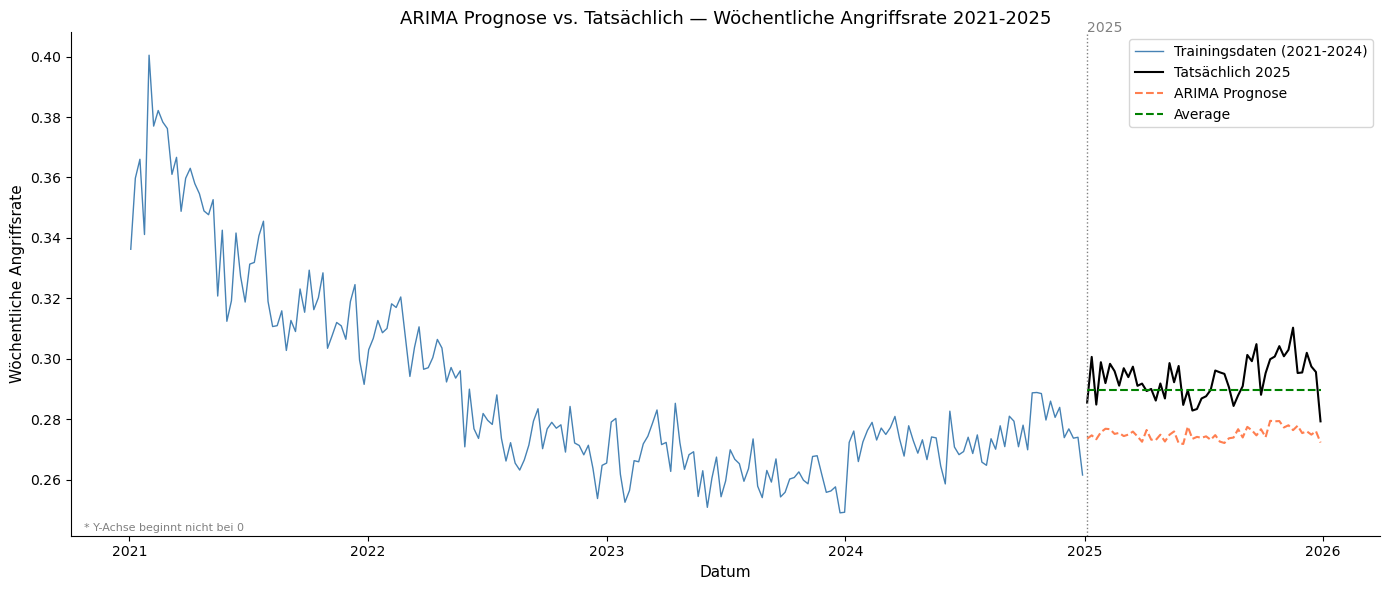

In [96]:
fig, ax = plt.subplots(figsize=(14, 6))

# Trainingsdaten
ax.plot(train.index, train.values,
        color='steelblue', linewidth=1,
        label='Trainingsdaten (2021-2024)')

# Tatsächliche 2025
ax.plot(test.index, test.values,
        color='black', linewidth=1.5,
        label='Tatsächlich 2025')

# ARIMA Prognose
ax.plot(forecast_arima.index, forecast_arima.values,
        color='coral', linewidth=1.5,
        linestyle='--', label='ARIMA Prognose')

# Trainingsdurchschnitt
ax.plot(test.index, train_avg.values,
        color='green', linewidth=1.5,
        linestyle='--', label='Average')

# Vertikale Linie
ax.axvline(x=test.index[0], color='gray',
           linestyle=':', linewidth=1)
ax.text(test.index[0], ax.get_ylim()[1],
        '2025', fontsize=10, color='gray')

ax.set_title('ARIMA Prognose vs. Tatsächlich — Wöchentliche Angriffsrate 2021-2025',
             fontsize=13)
ax.set_xlabel('Datum', fontsize=11)
ax.set_ylabel('Wöchentliche Angriffsrate', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate('* Y-Achse beginnt nicht bei 0',
            xy=(0.01, 0.01),
            xycoords='axes fraction',
            fontsize=8, color='gray')

plt.tight_layout()
plt.show()

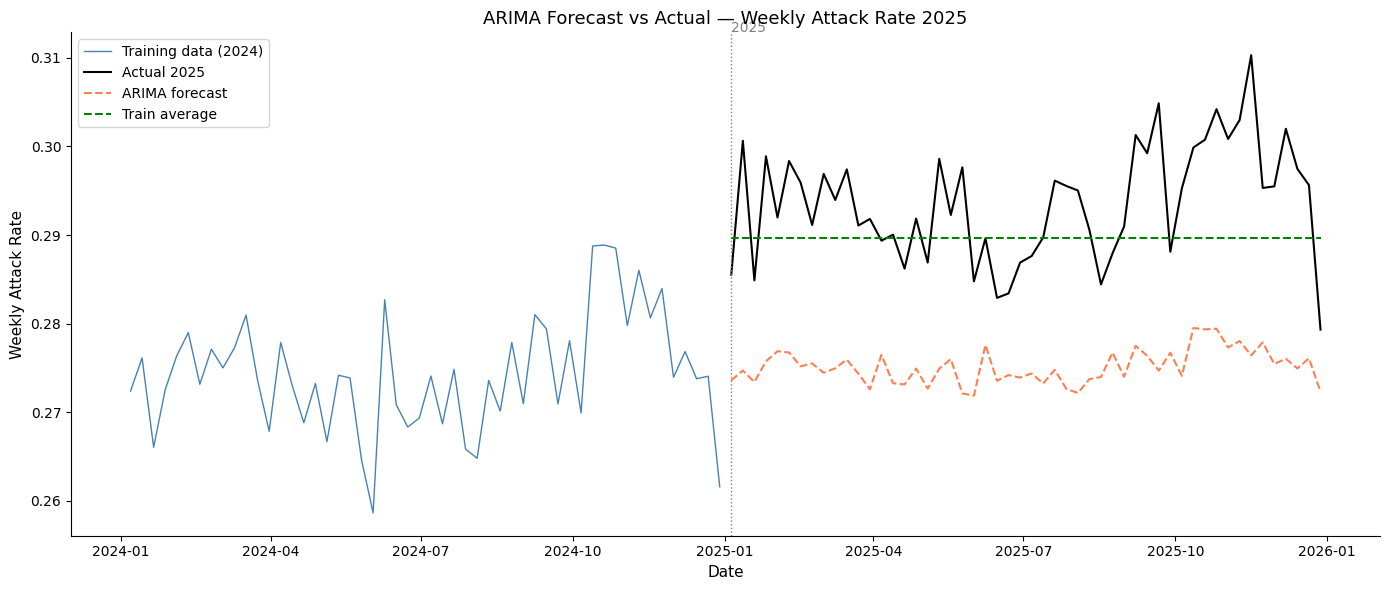

In [105]:
fig, ax = plt.subplots(figsize=(14, 6))

# only show last year of training for context
ax.plot(train.index[-52:], train.values[-52:],
        color='steelblue', linewidth=1,
        label='Training data (2024)')

# actual 2025
ax.plot(test.index, test.values,
        color='black', linewidth=1.5,
        label='Actual 2025')

# ARIMA forecast
ax.plot(forecast_arima.index, forecast_arima.values,
        color='coral', linewidth=1.5,
        linestyle='--', label='ARIMA forecast')

# train average baseline
ax.plot(test.index, train_avg.values,
        color='green', linewidth=1.5,
        linestyle='--', label='Train average')

# vertical line
ax.axvline(x=test.index[0], color='gray',
           linestyle=':', linewidth=1)
ax.text(test.index[0], ax.get_ylim()[1],
        '2025', fontsize=10, color='gray')

ax.set_title('ARIMA Forecast vs Actual — Weekly Attack Rate 2025', fontsize=13)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Weekly Attack Rate', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

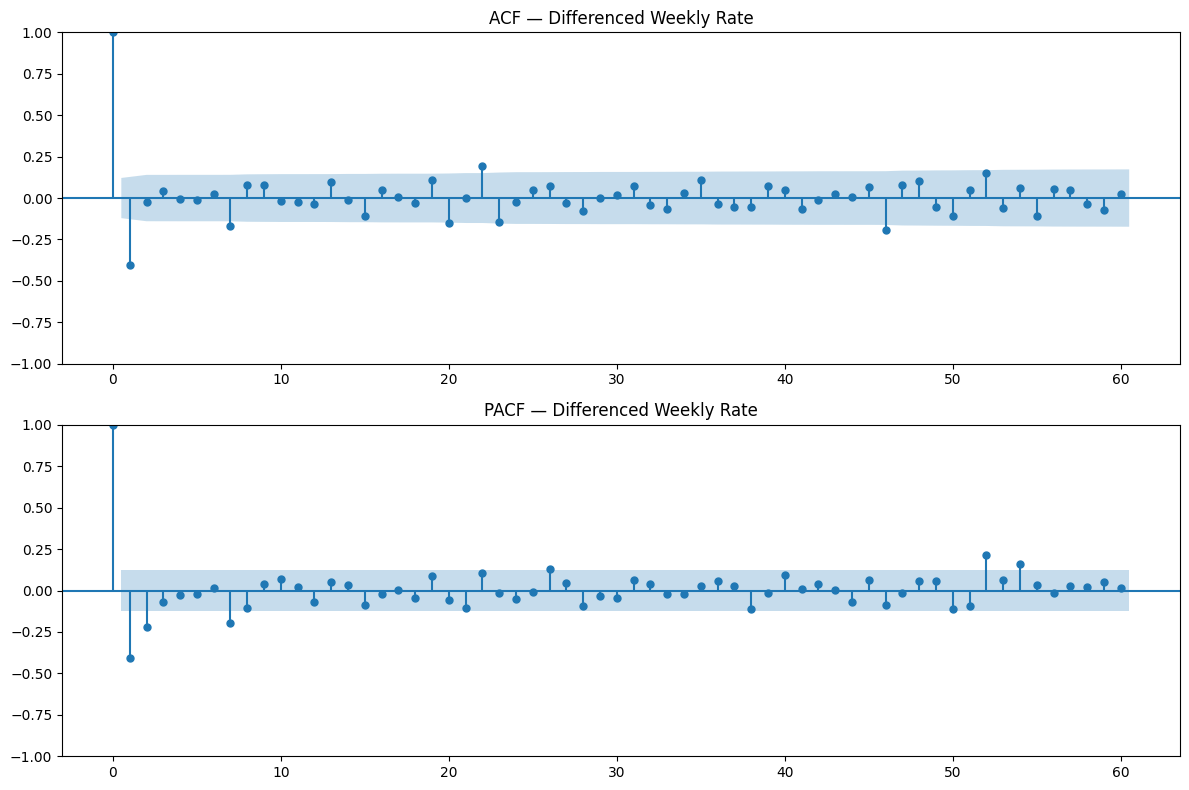

In [106]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(weekly_rate.diff().dropna(), lags=60, ax=axes[0])
plot_pacf(weekly_rate.diff().dropna(), lags=60, ax=axes[1])

axes[0].set_title('ACF — Differenced Weekly Rate', fontsize=12)
axes[1].set_title('PACF — Differenced Weekly Rate', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
model_acf = SARIMAX(train,
                    order=(3, 1, 2),
                    seasonal_order=(1, 0, 0, 52))

result_acf = model_acf.fit(disp=False)
print(f"AIC: {result_acf.aic:.3f}")
print(f"Ljung-Box: {result_acf.test_serial_correlation('ljungbox', lags=1)}")

# forecast and evaluate
forecast_acf = result_acf.forecast(steps=52)
forecast_acf = pd.Series(forecast_acf.values, index=test.index)

print(f"\nsMAPE: {smape(test.values, forecast_acf.values):.2f}%")
print(f"vs auto_arima sMAPE: 6.14%")

In [ ]:
from itertools import product

best_aic = np.inf
results_grid = []

p_values = [0, 1, 2]
d_values = [0, 1, 2]
q_values = [0, 1, 2]
P_values = [0, 1]
Q_values = [0, 1]

for p, d, q, P, Q in product(p_values, d_values,
                               q_values, P_values, Q_values):
    try:
        model = SARIMAX(train,
                        order=(p, d, q),
                        seasonal_order=(P, 0, Q, 52))
        result = model.fit(disp=False)
        results_grid.append({
            'params': (p, d, q, P, 0, Q),
            'aic': round(result.aic, 3)
        })
        print(f"ARIMA({p},{d},{q})({P},0,{Q})[52] → AIC={result.aic:.3f}")
    except:
        continue

best = min(results_grid, key=lambda x: x['aic'])
print(f"\nBest model: ARIMA{best['params']}")
print(f"Best AIC:   {best['aic']}")

In [ ]:
model_grid = SARIMAX(train,
                     order=(0, 1, 1),
                     seasonal_order=(1, 0, 0, 52))

result_grid = model_grid.fit(disp=False)

forecast_grid = result_grid.forecast(steps=52)
forecast_grid = pd.Series(forecast_grid.values, index=test.index)

print(f"Grid search ARIMA sMAPE: {smape(test.values, forecast_grid.values):.2f}%")
print(f"auto_arima ARIMA sMAPE:  6.14%")
print(f"Prophet sMAPE:           1.70%")

In [97]:
pip install Prophet

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple
  Using cached prophet-1.3.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.5 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.99-py3-none-any.whl.metadata (53 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (12.1 MB)
Using cached holidays-0.99-py3-none-any.whl (1.5 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [Prophet]m4/5 [Prophet]y]
Note: you may need to restart the kernel to use updated packages.


In [98]:
from prophet import Prophet

# prepare data
df_prophet = pd.DataFrame({
    'ds': weekly_rate.index,
    'y': weekly_rate.values
})

# split
train_prophet = df_prophet[df_prophet['ds'].dt.year <= 2024]
test_prophet  = df_prophet[df_prophet['ds'].dt.year == 2025]

# fit
model_prophet = Prophet(yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False)
model_prophet.fit(train_prophet)

# forecast
future = model_prophet.make_future_dataframe(periods=52, freq='W')
forecast = model_prophet.predict(future)

Importing plotly failed. Interactive plots will not work.
05:51:14 - cmdstanpy - INFO - Chain [1] start processing
05:51:14 - cmdstanpy - INFO - Chain [1] done processing


In [99]:
# make future dataframe for 52 weeks
future = model_prophet.make_future_dataframe(periods=52, freq='W')

# forecast
forecast_prophet = model_prophet.predict(future)

# get only 2025 predictions
forecast_prophet_2025 = forecast_prophet[
    forecast_prophet['ds'].dt.year == 2025
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print(forecast_prophet_2025.head(10).round(4))

            ds    yhat  yhat_lower  yhat_upper
209 2025-01-05  0.2792      0.2694      0.2897
210 2025-01-12  0.2847      0.2738      0.2952
211 2025-01-19  0.2877      0.2775      0.2980
212 2025-01-26  0.2892      0.2794      0.2990
213 2025-02-02  0.2915      0.2807      0.3009
214 2025-02-09  0.2953      0.2856      0.3061
215 2025-02-16  0.2983      0.2885      0.3090
216 2025-02-23  0.2985      0.2874      0.3088
217 2025-03-02  0.2964      0.2861      0.3070
218 2025-03-09  0.2943      0.2839      0.3047


In [100]:
# align prophet forecast with test data
prophet_pred = forecast_prophet_2025['yhat'].values[:len(test)]
prophet_pred = pd.Series(prophet_pred, index=test.index)

# evaluate
mae_prophet   = mae(test.values, prophet_pred.values)
rmse_prophet  = rmse(test.values, prophet_pred.values)
smape_prophet = smape(test.values, prophet_pred.values)

print(f"Prophet MAE:   {mae_prophet:.4f}")
print(f"Prophet RMSE:  {rmse_prophet:.4f}")
print(f"Prophet sMAPE: {smape_prophet:.2f}%")

Prophet MAE:   0.0050
Prophet RMSE:  0.0062
Prophet sMAPE: 1.70%


In [101]:
# align prophet forecast with test data
prophet_pred = forecast_prophet_2025['yhat'].values[:len(test)]
prophet_pred = pd.Series(prophet_pred, index=test.index)

# evaluate
mae_prophet   = mae(test.values, prophet_pred.values)
rmse_prophet  = rmse(test.values, prophet_pred.values)
smape_prophet = smape(test.values, prophet_pred.values)

print(f"Prophet MAE:   {mae_prophet:.4f}")
print(f"Prophet RMSE:  {rmse_prophet:.4f}")
print(f"Prophet sMAPE: {smape_prophet:.2f}%")

# comparison table
comparison = pd.DataFrame({
    'Date': test.index,
    'Actual': test.values.round(4),
    'Forecast': prophet_pred.values.round(4),
    'Difference': (test.values - prophet_pred.values).round(4),
    'Error %': (abs(test.values - prophet_pred.values) / test.values * 100).round(2)
})
comparison = comparison.set_index('Date')

print("\nWeekly Comparison — Actual vs Prophet Forecast 2025:")
print(comparison.to_string())
print(f"\nMean difference: {comparison['Difference'].mean():.4f}")
print(f"Max overestimate: {comparison['Difference'].min():.4f}")
print(f"Max underestimate: {comparison['Difference'].max():.4f}")

Prophet MAE:   0.0050
Prophet RMSE:  0.0062
Prophet sMAPE: 1.70%

Weekly Comparison — Actual vs Prophet Forecast 2025:
            Actual  Forecast  Difference  Error %
Date                                             
2025-01-05  0.2855    0.2792      0.0063     2.22
2025-01-12  0.3006    0.2847      0.0159     5.30
2025-01-19  0.2849    0.2877     -0.0028     0.98
2025-01-26  0.2989    0.2892      0.0097     3.26
2025-02-02  0.2920    0.2915      0.0004     0.15
2025-02-09  0.2984    0.2953      0.0031     1.03
2025-02-16  0.2959    0.2983     -0.0024     0.80
2025-02-23  0.2911    0.2985     -0.0074     2.54
2025-03-02  0.2969    0.2964      0.0005     0.17
2025-03-09  0.2940    0.2943     -0.0003     0.12
2025-03-16  0.2974    0.2939      0.0035     1.17
2025-03-23  0.2911    0.2947     -0.0036     1.24
2025-03-30  0.2918    0.2949     -0.0031     1.05
2025-04-06  0.2894    0.2942     -0.0049     1.68
2025-04-13  0.2900    0.2938     -0.0037     1.29
2025-04-20  0.2862    0.2944   

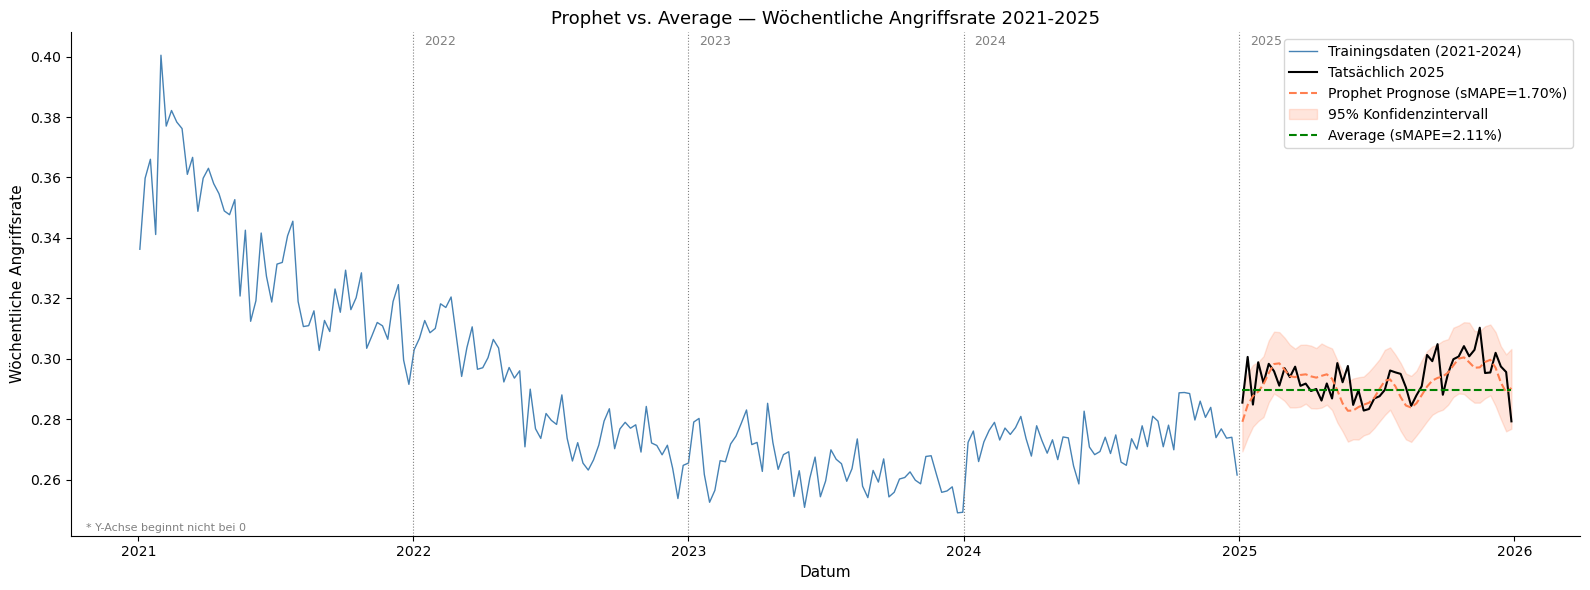

In [104]:
fig, ax = plt.subplots(figsize=(16, 6))

# Trainingsdaten
ax.plot(train.index, train.values,
        color='steelblue', linewidth=1,
        label='Trainingsdaten (2021-2024)')

# Tatsächliche 2025
ax.plot(test.index, test.values,
        color='black', linewidth=1.5,
        label='Tatsächlich 2025')

# Prophet Prognose
ax.plot(prophet_pred.index, prophet_pred.values,
        color='coral', linewidth=1.5,
        linestyle='--', label=f'Prophet Prognose (sMAPE={smape_prophet:.2f}%)')

# Konfidenzintervall
ax.fill_between(prophet_pred.index,
                forecast_prophet_2025['yhat_lower'].values[:len(test)],
                forecast_prophet_2025['yhat_upper'].values[:len(test)],
                color='coral', alpha=0.2,
                label='95% Konfidenzintervall')

# Trainingsdurchschnitt
ax.plot(test.index, train_avg.values,
        color='green', linewidth=1.5,
        linestyle='--', label=f'Average (sMAPE={smape(test.values, train_avg.values):.2f}%)')

# Vertikale Linien
for year in [2022, 2023, 2024, 2025]:
    ax.axvline(x=pd.Timestamp(f'{year}-01-01'),
               color='gray', linestyle=':', linewidth=0.8)
    ax.text(pd.Timestamp(f'{year}-01-15'),
            ax.get_ylim()[1] * 0.99,
            str(year), fontsize=9, color='gray')

ax.set_title('Prophet vs. Average — Wöchentliche Angriffsrate 2021-2025',
             fontsize=13)
ax.set_xlabel('Datum', fontsize=11)
ax.set_ylabel('Wöchentliche Angriffsrate', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate('* Y-Achse beginnt nicht bei 0',
            xy=(0.01, 0.01),
            xycoords='axes fraction',
            fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [134]:
# prepare daily data for Prophet
df_prophet_daily = pd.DataFrame({
    'ds': daily_rate.index,
    'y': daily_rate.values
})

# train test split
train_prophet_daily = df_prophet_daily[df_prophet_daily['ds'].dt.year <= 2024]
test_prophet_daily  = df_prophet_daily[df_prophet_daily['ds'].dt.year == 2025]

print(f"Train days: {len(train_prophet_daily)}")
print(f"Test days: {len(test_prophet_daily)}")
print(train_prophet_daily.head())

Train days: 1461
Test days: 365
          ds         y
0 2021-01-01  0.368421
1 2021-01-02  0.298246
2 2021-01-03  0.342105
3 2021-01-04  0.347826
4 2021-01-05  0.339130


In [135]:
from prophet import Prophet

model_prophet_daily = Prophet(
    yearly_seasonality=True,   # captures winter/summer pattern
    weekly_seasonality=True,   # captures Monday/Sunday pattern
    daily_seasonality=False    # no hourly pattern needed
)

model_prophet_daily.fit(train_prophet_daily)

# forecast 365 days ahead
future_daily = model_prophet_daily.make_future_dataframe(
    periods=365, 
    freq='D'
)

forecast_daily = model_prophet_daily.predict(future_daily)

# get only 2025 predictions
forecast_daily_2025 = forecast_daily[
    forecast_daily['ds'].dt.year == 2025
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print(f"Forecast rows: {len(forecast_daily_2025)}")
print(forecast_daily_2025.head(10).round(4))

09:24:44 - cmdstanpy - INFO - Chain [1] start processing
09:24:44 - cmdstanpy - INFO - Chain [1] done processing


Forecast rows: 365
             ds    yhat  yhat_lower  yhat_upper
1461 2025-01-01  0.2884      0.2678      0.3101
1462 2025-01-02  0.2902      0.2700      0.3115
1463 2025-01-03  0.2887      0.2681      0.3085
1464 2025-01-04  0.2880      0.2671      0.3081
1465 2025-01-05  0.2710      0.2499      0.2915
1466 2025-01-06  0.2714      0.2502      0.2901
1467 2025-01-07  0.2827      0.2629      0.3042
1468 2025-01-08  0.2927      0.2713      0.3127
1469 2025-01-09  0.2941      0.2747      0.3152
1470 2025-01-10  0.2921      0.2702      0.3138


In [136]:
# align forecast with actual
prophet_daily_pred = pd.Series(
    forecast_daily_2025['yhat'].values,
    index=test_prophet_daily['ds'].values
)

actual_daily = pd.Series(
    test_prophet_daily['y'].values,
    index=test_prophet_daily['ds'].values
)

# evaluate
mae_daily_prophet   = mae(actual_daily.values, prophet_daily_pred.values)
rmse_daily_prophet  = rmse(actual_daily.values, prophet_daily_pred.values)
smape_daily_prophet = smape(actual_daily.values, prophet_daily_pred.values)

print(f"Prophet Daily MAE:   {mae_daily_prophet:.4f}")
print(f"Prophet Daily RMSE:  {rmse_daily_prophet:.4f}")
print(f"Prophet Daily sMAPE: {smape_daily_prophet:.2f}%")

Prophet Daily MAE:   0.0078
Prophet Daily RMSE:  0.0099
Prophet Daily sMAPE: 2.68%


In [137]:
# aggregate daily prophet predictions to weekly
prophet_daily_weekly = prophet_daily_pred.resample('W').mean()
actual_weekly_2025 = actual_daily.resample('W').mean()

mae_agg   = mae(actual_weekly_2025.values, prophet_daily_weekly.values)
rmse_agg  = rmse(actual_weekly_2025.values, prophet_daily_weekly.values)
smape_agg = smape(actual_weekly_2025.values, prophet_daily_weekly.values)

print(f"Daily Prophet aggregated to weekly:")
print(f"MAE:   {mae_agg:.4f}")
print(f"RMSE:  {rmse_agg:.4f}")
print(f"sMAPE: {smape_agg:.2f}%")

Daily Prophet aggregated to weekly:
MAE:   0.0049
RMSE:  0.0061
sMAPE: 1.66%


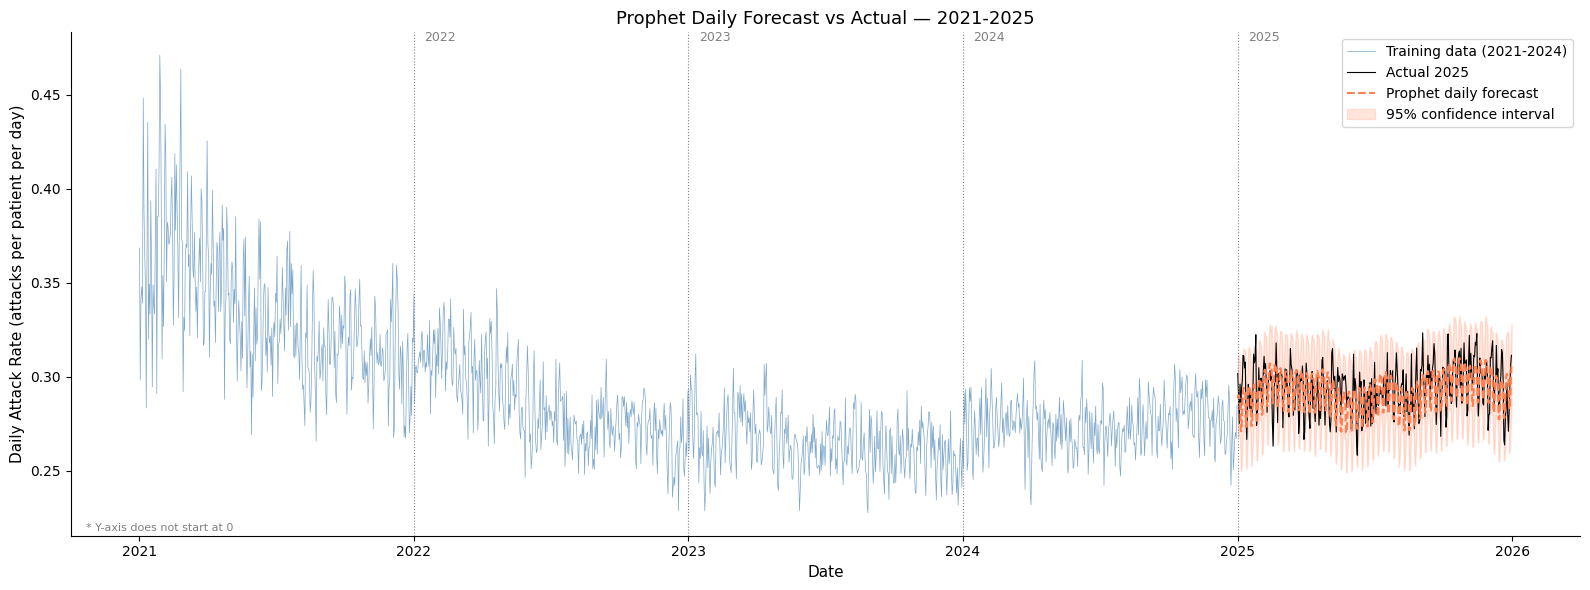

In [138]:
fig, ax = plt.subplots(figsize=(16, 6))

# full training data
ax.plot(train_prophet_daily['ds'], train_prophet_daily['y'],
        color='steelblue', linewidth=0.5,
        label='Training data (2021-2024)', alpha=0.7)

# actual 2025
ax.plot(test_prophet_daily['ds'], test_prophet_daily['y'],
        color='black', linewidth=0.8,
        label='Actual 2025')

# prophet daily forecast
ax.plot(forecast_daily_2025['ds'], forecast_daily_2025['yhat'],
        color='coral', linewidth=1.5,
        linestyle='--', label='Prophet daily forecast')

# confidence interval
ax.fill_between(forecast_daily_2025['ds'],
                forecast_daily_2025['yhat_lower'],
                forecast_daily_2025['yhat_upper'],
                color='coral', alpha=0.2,
                label='95% confidence interval')

# vertical lines separating each year
for year in [2022, 2023, 2024, 2025]:
    ax.axvline(x=pd.Timestamp(f'{year}-01-01'),
               color='gray', linestyle=':', linewidth=0.8)
    ax.text(pd.Timestamp(f'{year}-01-15'),
            ax.get_ylim()[1] * 0.99,
            str(year), fontsize=9, color='gray')

ax.set_title('Prophet Daily Forecast vs Actual — 2021-2025', fontsize=13)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Daily Attack Rate (attacks per patient per day)', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate('* Y-axis does not start at 0',
            xy=(0.01, 0.01),
            xycoords='axes fraction',
            fontsize=8, color='gray')

plt.tight_layout()
plt.show()

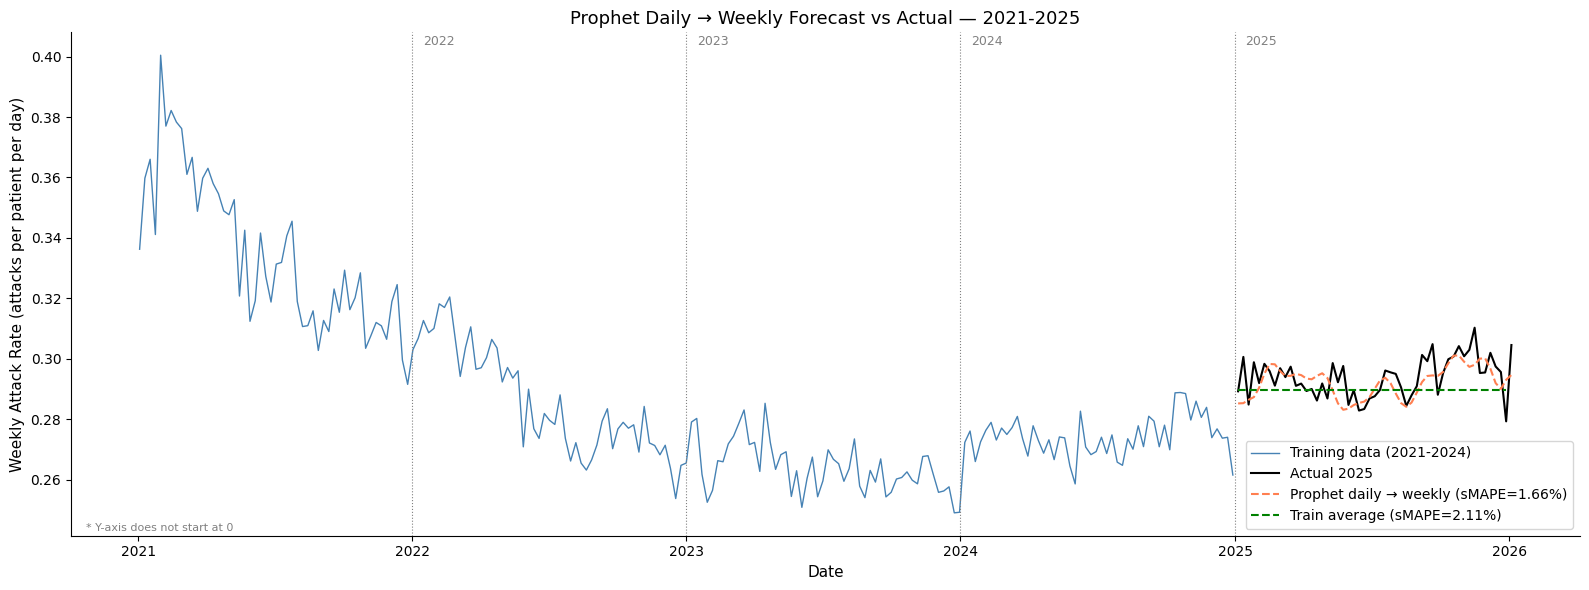

In [146]:
fig, ax = plt.subplots(figsize=(16, 6))

# full training data weekly
ax.plot(train.index, train.values,
        color='steelblue', linewidth=1,
        label='Training data (2021-2024)')

# actual 2025 weekly
ax.plot(actual_weekly_2025.index, actual_weekly_2025.values,
        color='black', linewidth=1.5,
        label='Actual 2025')

# prophet daily aggregated to weekly
ax.plot(prophet_daily_weekly.index, prophet_daily_weekly.values,
        color='coral', linewidth=1.5,
        linestyle='--', label=f'Prophet daily → weekly (sMAPE={smape_agg:.2f}%)')

# train average
ax.plot(test.index, train_avg.values,
        color='green', linewidth=1.5,
        linestyle='--', label=f'Train average (sMAPE={smape(test.values, train_avg.values):.2f}%)')

# vertical lines separating each year
for year in [2022, 2023, 2024, 2025]:
    ax.axvline(x=pd.Timestamp(f'{year}-01-01'),
               color='gray', linestyle=':', linewidth=0.8)
    ax.text(pd.Timestamp(f'{year}-01-15'),
            ax.get_ylim()[1] * 0.99,
            str(year), fontsize=9, color='gray')

ax.set_title('Prophet Daily → Weekly Forecast vs Actual — 2021-2025',
             fontsize=13)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Weekly Attack Rate (attacks per patient per day)', fontsize=11)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate('* Y-axis does not start at 0',
            xy=(0.01, 0.01),
            xycoords='axes fraction',
            fontsize=8, color='gray')

plt.tight_layout()
plt.show()

In [ ]:
# This is the end 